# Import libraries

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from plotly import express as px
import plotly.figure_factory as ff

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import IsolationForest
from umap import UMAP

from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.base import BaseEstimator
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.metrics import *

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV, LassoCV
import optuna


from sklearn.base import BaseEstimator, RegressorMixin
from inspect import signature
from sklearn.utils.class_weight import compute_sample_weight
# import warnings
# warnings.filterwarnings("ignore")

SEED = 17
compare_metric_name = "RMSE"
N_TRIALS = 100
METRICS_NAMES: dict[str, callable] = {
    "Accuracy": accuracy_score,
    "Balanced Accuracy": balanced_accuracy_score,
    "F1": f1_score,
    "F1 (Micro)": lambda y_true, y_pred: f1_score(y_true, y_pred, average="micro"),
    "F1 (Macro)": lambda y_true, y_pred: f1_score(y_true, y_pred, average="macro"),
    "F1 (Weighted)": lambda y_true, y_pred: f1_score(y_true, y_pred, average="weighted"),
    "Recall": recall_score,
    "Precision": precision_score,
    "Roc AUC": roc_auc_score,
    "MAE": mean_absolute_error,
    "MAPE": mean_absolute_percentage_error,
    "MSE": mean_squared_error,
    "RMSE": root_mean_squared_error,
    "RMSLE": root_mean_squared_log_error,
    "R2": r2_score,
}

METRICS = {
    key: [
        eval_func,
        "preds" if key not in ["Roc AUC", "Mean Average Precision"] else "probs",
        "minimize" if key in ["MAE", "MAPE", "MSE", "RMSE", "RMSLE"] else "maximize"
    ]
    for key, eval_func in METRICS_NAMES.items()
}

# Utility functions

In [1]:
def base_information(data):
    df = pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum() / data.shape[0] * 100
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    df = df.reset_index().rename(columns={'index': 'Column'})
    styled_df = (
        df
        .style
        .set_caption("📝 Base Information")
        .format({
            'Number of missing values': '{:,.0f}',
            'Percentage of missing values': '{:.2f}%',
            'Unique values': '{:,.0f}',
            'Count': '{:,.0f}'
        })
        .bar(subset=['Percentage of missing values'], color='#4a90e2', vmin=0, vmax=100)
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'), ('border', '1px solid #ddd')]}])
    )
    return styled_df

def get_categorical_columns(df: pd.DataFrame) -> list[str]:
    """
    Get categorical columns from the DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
    
    Returns:
        list[str]: List of categorical columns.
    """
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns
    categorical_columns = [col for col in categorical_columns if df[col].nunique() < 100]
    categorical_columns = list(set(categorical_columns) | set(df.columns[df.nunique() == 2]))
    return categorical_columns

NameError: name 'pd' is not defined

In [3]:
def fit_and_predict(algorithm: BaseEstimator, X_train: pd.DataFrame, y_train: pd.Series, X_valid: pd.DataFrame, y_valid: pd.Series, metric_type: str = "preds") -> tuple[np.ndarray, np.ndarray]:
    """
    Fit the algorithm on training data and predict on test data.
    
    Args:
        algorithm (BaseEstimator): Algorithm to fit and predict.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_valid (pd.DataFrame): Validation features.
        y_valid (pd.Series, optional): Validation target.
        metric_type (str, optional): Type of metric to use for prediction. Defaults to "preds".
    
    Returns:
        tuple[np.ndarray, np.ndarray]: Tuple of predicted values for training and validation sets.
    """
    sig = signature(algorithm.fit)
    fit_params = {}
    if "eval_set" in sig.parameters:
        fit_params["eval_set"] = [(X_valid, y_valid)]
    if "verbose" in sig.parameters:
        fit_params["verbose"] = False
    if "X_val" and "y_val" in sig.parameters:
        fit_params["X_val"] = X_valid
        fit_params["y_val"] = y_valid
    # if "sample_weight" in sig.parameters:
    #     fit_params["sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_train)
    algorithm.fit(X_train, y_train, **fit_params)
    
    if metric_type == "preds":
        y_train_pred = algorithm.predict(X_train)
        y_test_pred = algorithm.predict(X_valid)
    elif metric_type == "probs":
        y_train_pred = algorithm.predict_proba(X_train)
        y_test_pred = algorithm.predict_proba(X_valid)
    else:
        raise ValueError(f"Unknown metric type {metric_type}")
    return y_train_pred, y_test_pred

def postprocess_predictions(y_pred: np.ndarray, min_value: float = 0, max_value: float = None) -> np.ndarray:
    """
    Postprocess predictions to ensure they are within specified bounds.
    
    Args:
        y_pred (np.ndarray): Predicted values.
        min_value (float, optional): Minimum value for predictions. Defaults to 0.
        max_value (float, optional): Maximum value for predictions. Defaults to None.
    
    Returns:
        np.ndarray: Postprocessed predictions.
    """
    if max_value is not None:
        y_pred = np.clip(y_pred, a_min=min_value, a_max=max_value)
    else:
        y_pred = np.clip(y_pred, a_min=min_value)
    return y_pred

def perform_cv(X: pd.DataFrame, y: pd.Series, algorithm: object, cv: sklearn.model_selection = KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name: str = "RMSE") -> tuple[list[float], list[float]]:
    """
    Perform cross-validation and return list of scores
    
    Args:
        X (pd.DataFrame): input data
        y (pd.Series): target data
        algorithm (Any): algorithm to use for training and prediction
        cv (sklearn.model_selection, default=KFold(n_splits=5, shuffle=True, random_state=SEED)): cross-validation strategy
        metric_name (str, default="RMSE"): metric name to use for evaluation
    
    Returns:
        tuple[list[float], list[float]]: Tuple of lists of train and validation scores
    """
    if metric_name not in METRICS.keys():
        raise ValueError(f"Metric {metric_name} not found in METRICS dictionary")
    eval_metric = METRICS[metric_name][0]
    metric_type = METRICS[metric_name][1]
    train_scores, validation_scores = [], []
    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        y_train_pred, y_valid_pred = fit_and_predict(algorithm, X_train, y_train, X_valid, y_valid, metric_type)
        train_scores.append(eval_metric(y_train, y_train_pred))
        validation_scores.append(eval_metric(y_valid, y_valid_pred))
    return train_scores, validation_scores

In [4]:
class Plots:
    def homoscedacity_plot(self, y_true, y_pred, metric="rmse"):
        if metric not in METRICS:
            raise ValueError('Unsupported metric: {}'.format(metric))
        eval_metric_value = METRICS[metric][0](y_true, y_pred)
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        residuals = y_true - y_pred
        fig = px.scatter(x=y_pred, y=residuals, labels={"x": "Fitted values",  "y": "Residuals"})
        fig.add_shape(type="line", line_color="red", line_width=2, opacity=0.5, line_dash="dash",x0=0, x1=1, xref="paper", y0=0, y1=0, yref="y")
        fig.update_layout(template="simple_white", width=1200, height=1000, title=f"<b>Homoscedacity plot ({metric.upper()}: {eval_metric_value:.4f})<b>", title_x=0.5, xaxis_title="Fitted values", yaxis_title="Residuals", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def true_vs_fitted_plot(self, y_true, y_pred, metric="RMSE"):
        if metric not in METRICS:
            raise ValueError('Unsupported metric: {}'.format(metric))
        eval_metric_value = METRICS[metric][0](y_true, y_pred)
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        fig = px.scatter(x=y_pred, y=y_true, labels={"x": "Fitted values",  "y": "True values"}, trendline="ols", trendline_color_override="green")
        fig.data[1].line.width = 8
        fig.update_layout(template="simple_white", width=1200, height=1000, xaxis_title="Fitted values", yaxis_title="True values", title=f"<b>True vs Fitted plot ({metric.upper()}: {eval_metric_value:.4f})<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.update_xaxes(range=[np.min(y_pred) - 0.01 * np.min(y_pred), np.max(y_pred) + 0.01 * np.max(y_pred)])
        fig.update_yaxes(range=[np.min(y_true) - 0.01 * np.min(y_true), np.max(y_true) + 0.01 * np.max(y_true)])
        fig.show("png")

plots = Plots()

# Load dataset

In [5]:
data = pd.read_csv("../data/data_feature_engineered.csv")
# data = data[:1000]
target_feature = "log_price"
categorical_features = ['Condition', 'Vehicle_brand', 'Vehicle_model', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Colour', 'Origin_country', 'First_registration_year', 'First_registration_month', 'Offer_publication_day', 'Offer_publication_weekday', 'wojewodztwo', 'feature_ABS', 'feature_Central locking', 'feature_Electric front windows', 'feature_Drivers airbag', 'feature_Power steering', 'feature_Passengers airbag', 'feature_Electrically adjustable mirrors', 'feature_Factory radio', 'feature_Immobilizer', 'feature_On-board computer', 'feature_ESP(stabilization of the track)', 'feature_Alloy wheels', 'feature_CD', 'feature_ASR (traction control)', 'feature_Multifunction steering wheel', 'feature_Automatic air conditioning', 'feature_Isofix', 'feature_Front side airbags', 'feature_Fog lights', 'feature_Electric rear windows', 'feature_Cruise control', 'feature_Heated side mirrors', 'feature_Air curtains', 'feature_Rear parking sensors', 'feature_Bluetooth', 'feature_Rain sensor', 'feature_Alarm', 'feature_Daytime running lights', 'is_luxury_brand', 'high_mileage_flag', 'feature_count_bucket', 'is_weekend_offer', 'brand_region_interaction', 'is_old_low_km']
for feature in categorical_features:
    data[feature] = data[feature].astype("category")
data.drop(columns=["Vehicle_model", "brand_region_interaction"], axis=1, inplace=True)
data

,Condition,Vehicle_brand,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,Drive,Transmission,Type,...,feature_Alarm,feature_Daytime running lights,age_at_sale,power_to_weight_ratio,mileage_per_year,is_luxury_brand,high_mileage_flag,feature_count_bucket,is_weekend_offer,is_old_low_km
0,New,Other,2021,1.0,145.0,1400.0,Gasoline,Front wheels,Manual,small_cars,...,False,False,0,103.571429,1.000000,False,0,Low,False,0
1,Used,Other,2018,52000.0,180.0,1368.0,Gasoline,Front wheels,Automatic,small_cars,...,True,False,3,131.578947,17333.333333,False,0,Medium,False,0
2,Used,Other,2012,29000.0,160.0,1368.0,Gasoline,Front wheels,Manual,small_cars,...,False,False,9,116.959064,3222.222222,False,0,Medium,False,0
3,New,Other,2021,600.0,165.0,1368.0,Gasoline,Front wheels,Manual,small_cars,...,False,True,0,120.614035,600.000000,False,0,Medium,False,0
4,Used,Other,2016,46060.0,180.0,1368.0,Gasoline,Front wheels,Manual,small_cars,...,True,True,5,131.578947,9212.000000,False,0,Medium,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200927,Used,Other,1988,47986.0,50.0,993.0,Gasoline,Front wheels,Manual,sedan,...,False,False,33,50.352467,1454.121212,False,0,Low,True,1
200928,Used,Other,1987,89700.0,50.0,993.0,Gasoline,Front wheels,Manual,sedan,...,False,False,34,50.352467,2638.235294,False,0,Low,True,1
200929,Used,Other,1990,75000.0,72.0,1272.0,Gasoline,Front wheels,Manual,sedan,...,False,False,31,56.603774,2419.354839,False,0,Low,False,1
200930,Used,Other,1989,32500.0,95.0,2445.0,Gasoline,Front wheels,Manual,sedan,...,False,False,32,38.854806,1015.625000,False,0,Low,False,1


In [6]:
base_information(data)

,Column,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
0,Condition,category,0,0.00%,2,"200,932"
1,Vehicle_brand,category,0,0.00%,21,"200,932"
2,Production_year,int64,0,0.00%,37,"200,932"
3,Mileage_km,float64,0,0.00%,"51,054","200,932"
4,Power_HP,float64,0,0.00%,481,"200,932"
5,Displacement_cm3,float64,0,0.00%,965,"200,932"
6,Fuel_type,category,0,0.00%,5,"200,932"
7,Drive,category,0,0.00%,5,"200,932"
8,Transmission,category,0,0.00%,2,"200,932"
9,Type,category,0,0.00%,9,"200,932"


## Split dataset

In [7]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=SEED, shuffle=True)
train_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)

In [8]:
numerical_features = data.select_dtypes(exclude=["category"]).columns.tolist()
categorical_features = data.select_dtypes(include=["category"]).columns.tolist()
if target_feature in categorical_features:
    label2id = {label: idx for idx, label in enumerate(train_data[target_feature].cat.categories)}
    id2label = {idx: label for label, idx in label2id.items()}
    print(id2label)
    train_data[target_feature] = train_data[target_feature].cat.codes
    categorical_features.remove(target_feature)
    num_classes = len(label2id)
independent_features = train_data.columns.difference([target_feature]).tolist()
independent_features_types = [(feature, train_data[feature].dtype) for feature in independent_features]
print("Independent features and their types:")
for feature, dtype in independent_features_types:
    print(f"- {feature} ({dtype}):", end="\n")

Independent features and their types:
- Colour (category):
- Condition (category):
- Displacement_cm3 (float64):
- Doors_number (int64):
- Drive (category):
- Features_count (int64):
- First_registration_month (category):
- First_registration_year (category):
- Fuel_type (category):
- Mileage_km (float64):
- Offer_publication_day (category):
- Offer_publication_weekday (category):
- Origin_country (category):
- Power_HP (float64):
- Production_year (int64):
- Transmission (category):
- Type (category):
- Vehicle_brand (category):
- age_at_sale (int64):
- feature_ABS (category):
- feature_ASR (traction control) (category):
- feature_Air curtains (category):
- feature_Alarm (category):
- feature_Alloy wheels (category):
- feature_Automatic air conditioning (category):
- feature_Bluetooth (category):
- feature_CD (category):
- feature_Central locking (category):
- feature_Cruise control (category):
- feature_Daytime running lights (category):
- feature_Drivers airbag (category):
- feature

# Modeling

## Base models

### LightGBM

In [9]:
model = LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1, objective='regression', metric='rmse', linear_tree=True, early_stopping_rounds=100)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.2444 +- 0.0038
Validation RMSE: 0.2540 +- 0.0045


### XGBoost

In [10]:
model = XGBRegressor(random_state=SEED, n_jobs=-1, objective='reg:squarederror', eval_metric='rmse', enable_categorical=True, tree_method='hist', early_stopping_rounds=100)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.2111 +- 0.0009
Validation RMSE: 0.2495 +- 0.0015


### Histogram-based Gradient Boosting

In [11]:
model = HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features, early_stopping=True, scoring='neg_root_mean_squared_error', verbose=0)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.2455 +- 0.0007
Validation RMSE: 0.2544 +- 0.0015


### CatBoost

In [12]:
model = CatBoostRegressor(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='RMSE', eval_metric='RMSE', early_stopping_rounds=100)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.2249 +- 0.0004
Validation RMSE: 0.2422 +- 0.0021


## Ensemble model

In [13]:
class EnsembleWeightTunerCV:
    def __init__(
        self,
        estimators: list,
        metric: str,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        n_trials: int = 50,
        seed: int = 17
    ):
        self.estimators = estimators
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed

        if metric not in METRICS:
            raise ValueError(f"Unsupported metric: {metric}. Supported: {', '.join(METRICS.keys())}")
        self.eval_metric = METRICS[metric][0]
        self.metric_type = METRICS[metric][1]
        self.direction = METRICS[metric][2]

    def tune(self, X, y) -> optuna.Study:
        # X_sample = X.sample(n=min(20000, X.shape[0]))
        # y_sample = y[X_sample.index]
        X_sample = X.sample(n=min(X.shape[0], X.shape[0]))
        y_sample = y[X_sample.index]
        y_true, y_pred = self.perform_cv(X_sample, y_sample)
        study = self.create_study()
        study.optimize(
            lambda trial: self.objective(trial, y_true, y_pred),
            n_trials=self.n_trials,
        )
        self.best_weights = np.array([study.best_params[f"w{i}"] for i in range(len(self.estimators))])
        self.best_weights = self.best_weights / self.best_weights.sum()
        return study
    
    def create_study(self) -> optuna.study.Study:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Weight Tuning Study",
        )

    def objective(self, trial, y_true, y_pred):
        weights = np.array([trial.suggest_float(f"w{i}", 0.01, 0.99) for i in range(len(self.estimators))])
        weights /= weights.sum()
        blended = sum(w * p for w, p in zip(weights, y_pred))
        # For regression, metric_type is usually "preds"
        return self.eval_metric(y_true, blended)

    def perform_cv(self, X: pd.DataFrame, y: pd.Series) -> tuple:
        y_valid_true = []
        y_valid_pred = [[] for _ in range(len(self.estimators))]
        for train_idx, valid_idx in self.cv.split(X, y):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            y_valid_true.extend(y_valid.tolist())
            for i, estimator in enumerate(self.estimators):
                _, pred = fit_and_predict(
                    estimator, X_train, y_train, X_valid, y_valid, metric_type=self.metric_type
                )
                y_valid_pred[i].extend(pred.tolist())
        y_valid_true = np.array(y_valid_true)
        y_valid_pred = [np.array(pred) for pred in y_valid_pred]
        return y_valid_true, y_valid_pred

    @staticmethod
    def check_X(X: object) -> pd.DataFrame:
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def check_y(y: object) -> pd.Series:
        return y if isinstance(y, pd.Series) else pd.Series(y)
    

ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators = [
    LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1, objective='regression', metric='rmse', linear_tree=True, early_stopping_rounds=100),
    XGBRegressor(random_state=SEED, n_jobs=-1, objective='reg:squarederror', eval_metric='rmse', enable_categorical=True, tree_method='hist', early_stopping_rounds=100),
    HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features, early_stopping=True, scoring='neg_root_mean_squared_error', verbose=0),
    CatBoostRegressor(random_state=SEED, verbose=0, cat_features=categorical_features, task_type='GPU', loss_function='RMSE', eval_metric='RMSE', early_stopping_rounds=100)
],
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS*2,
    seed=SEED
)
ensemble_weights_tuner.tune(train_data[independent_features], train_data[target_feature])
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}")

[I 2025-06-16 07:57:52,373] A new study created in memory with name: Weight Tuning Study
[I 2025-06-16 07:57:52,377] Trial 0 finished with value: 0.24534800515669344 and parameters: {'w0': 0.2987717026333675, 'w1': 0.5299750204931882, 'w2': 0.19769037120854496, 'w3': 0.07654235102746554}. Best is trial 0 with value: 0.24534800515669344.
[I 2025-06-16 07:57:52,379] Trial 1 finished with value: 0.244525889074381 and parameters: {'w0': 0.7812457507999151, 'w1': 0.6532068513403384, 'w2': 0.6347704781227631, 'w3': 0.5740908358779733}. Best is trial 1 with value: 0.244525889074381.
[I 2025-06-16 07:57:52,379] Trial 2 finished with value: 0.2484810117819061 and parameters: {'w0': 0.04828165786508915, 'w1': 0.3606573323938779, 'w2': 0.9367695230820394, 'w3': 0.06884378670907763}. Best is trial 1 with value: 0.244525889074381.
[I 2025-06-16 07:57:52,392] Trial 3 finished with value: 0.24307956518756327 and parameters: {'w0': 0.8567612614752868, 'w1': 0.8697447156250696, 'w2': 0.0601697923080446

Estimator 0: LGBMRegressor, Weight: 0.0069
Estimator 1: XGBRegressor, Weight: 0.3308
Estimator 2: HistGradientBoostingRegressor, Weight: 0.0094
Estimator 3: CatBoostRegressor, Weight: 0.6530


## Hyperparameter tuning

In [14]:
class RandomSearchCV:
    def __init__(
        self,
        algorithm: object,
        metric: str,
        cv: sklearn.model_selection.BaseCrossValidator = StratifiedKFold(n_splits=5, shuffle=True, random_state=17),
        n_trials: int = 100,
        seed: int = 17,
        gap_weight: float = 0.3,
    ):
        self.algorithm = algorithm
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed
        self.gap_weight = gap_weight

        if metric not in METRICS:
            raise ValueError(f"Unsupported metric: {metric}. Supported metrics are: {', '.join(METRICS.keys())}")
        self.eval_metric = METRICS[metric][0]
        self.metric_type = METRICS[metric][1]
        self.direction = METRICS[metric][2]

    def tune(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        params_grid: dict[str, tuple[str, list[object]]],
        X_valid: pd.DataFrame = None,
        y_valid: pd.Series = None,
    ) -> optuna.study.Study:
        self.params_grid = params_grid
        study = self.create_study()
        X, y = self.check_X(X), self.check_y(y)
        if X_valid is not None and y_valid is not None:
            X_valid = self.check_X(X_valid)
            y_valid = self.check_y(y_valid)
            study.optimize(lambda trial: self.objective(trial, X, y, X_valid, y_valid), n_trials=self.n_trials)
        else:
            study.optimize(lambda trial: self.objective_cv(trial, X, y), n_trials=self.n_trials)
        return study

    def create_study(self) -> optuna.study.Study:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Optuna tuning"
        )

    def get_param(self, trial: optuna.Trial, param_name: str, param_values: tuple[str, list[object]]) -> object:
        param_type, param_value = param_values
        if param_type == "int":
            return trial.suggest_int(param_name, *param_value)
        elif param_type == "float":
            return trial.suggest_float(param_name, *param_value, log=True)
        elif param_type == "categorical":
            return trial.suggest_categorical(param_name, param_value)
        elif param_type == "constant":
            return param_value[0]

    def objective(self, trial: optuna.Trial, X_train: pd.DataFrame, y_train: pd.Series, X_valid: pd.DataFrame, y_valid: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        model = self.algorithm.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid) if self.metric_type == "preds" else model.predict_proba(X_valid)
        return self.eval_metric(y_valid, preds)

    def objective_cv(self, trial: optuna.Trial, X: pd.DataFrame, y: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        # self.algorithm.set_params(**params)
        self.algorithm = self.algorithm.__class__(**params)
        X_sample = X.sample(n=min(100000, X.shape[0]))
        y_sample = y[X_sample.index]
        valid_scores = []
        for train_idx, valid_idx in self.cv.split(X_sample, y_sample):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            _, y_valid_pred = fit_and_predict(
                self.algorithm, X_train, y_train, X_valid, y_valid, metric_type=self.metric_type
            )
            valid_scores.append(self.eval_metric(y_valid, y_valid_pred))
        mean_valid = np.mean(valid_scores)
        return mean_valid

    @staticmethod
    def check_X(X: object) -> pd.DataFrame:
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def check_y(y: object) -> pd.Series:
        return y if isinstance(y, pd.Series) else pd.Series(y)

### LightGBM

In [15]:
model = LGBMRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "objective": ("constant", ["regression"]),
    "metric": ("constant", ["rmse"]),
    "boosting_type": ("constant", ["gbdt"]),
    "seed": ("constant", [SEED]),
    "linear_tree": ("constant", [True]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "early_stopping_rounds": ("constant", [100]),
}
tunable_params_grid = {
    "n_estimators": ("int", [50, 1000]),
    "learning_rate": ("float", [1e-3, 0.3]),
    "num_leaves": ("int", [10, 450]),
    "max_depth": ("int", [3, 30]),
    "min_child_samples": ("int", [10, 300]),
    "subsample": ("float", [0.3, 1.0]),
    "colsample_bytree": ("float", [0.3, 1.0]),
    "reg_alpha": ("float", [1e-3, 10]),
    "reg_lambda": ("float", [1e-3, 10]),
    "min_split_gain": ("float", [1e-3, 1.0])
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
lgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
lgbm_best_params = {**constant_params, **lgbm_best_params}
print(lgbm_best_params)

[I 2025-06-16 07:57:54,563] A new study created in memory with name: Optuna tuning
[I 2025-06-16 07:57:58,320] Trial 0 finished with value: 0.27173101704805136 and parameters: {'n_estimators': 330, 'learning_rate': 0.0206218550445619, 'num_leaves': 94, 'max_depth': 4, 'min_child_samples': 239, 'subsample': 0.6611562428979949, 'colsample_bytree': 0.6463494460474463, 'reg_alpha': 0.200637253882253, 'reg_lambda': 0.0014330180633302001, 'min_split_gain': 0.011842429649211153}. Best is trial 0 with value: 0.27173101704805136.
[I 2025-06-16 08:00:24,155] Trial 1 finished with value: 0.37729700488957707 and parameters: {'n_estimators': 949, 'learning_rate': 0.001408438713195345, 'num_leaves': 391, 'max_depth': 27, 'min_child_samples': 24, 'subsample': 0.6580472549057305, 'colsample_bytree': 0.5829352503057804, 'reg_alpha': 0.24550085725408072, 'reg_lambda': 0.0859240021375131, 'min_split_gain': 0.007062597926314823}. Best is trial 0 with value: 0.27173101704805136.
[I 2025-06-16 08:00:51,590]

{'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'seed': 17, 'linear_tree': True, 'verbose': -1, 'n_jobs': -1, 'early_stopping_rounds': 100, 'n_estimators': 935, 'learning_rate': 0.02353999479003764, 'num_leaves': 266, 'max_depth': 23, 'min_child_samples': 153, 'subsample': 0.6549934217951778, 'colsample_bytree': 0.43036609356050237, 'reg_alpha': 0.0026849783655687235, 'reg_lambda': 0.0027494339497923627, 'min_split_gain': 0.004865899648445306}


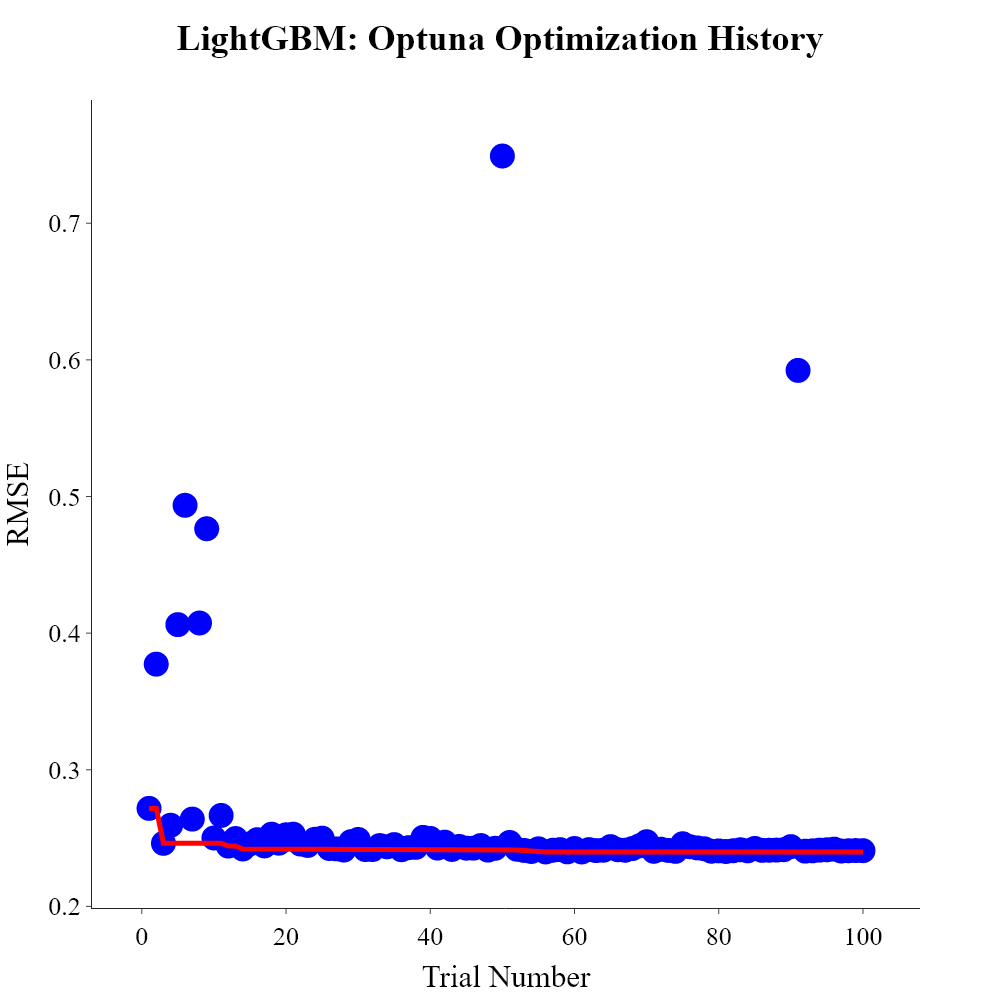

In [16]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

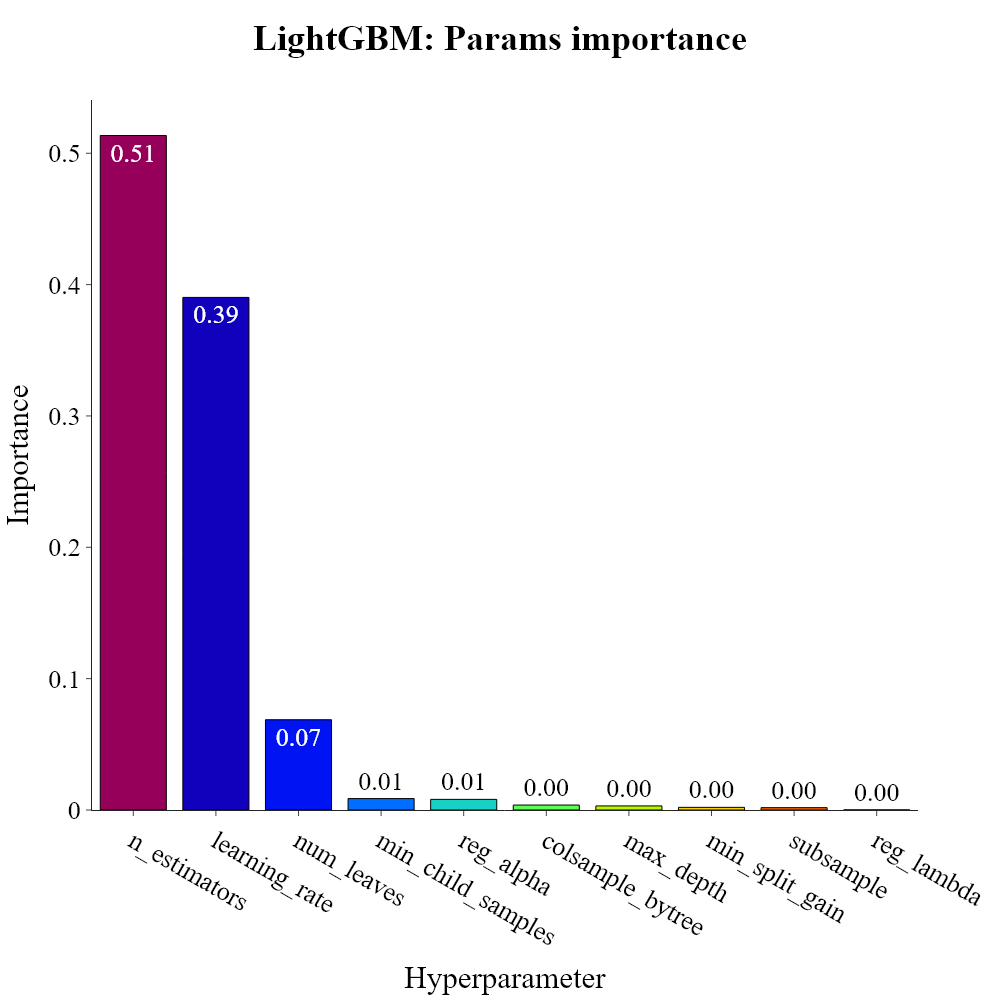

In [17]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [18]:
model = LGBMRegressor(**lgbm_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.1609 +- 0.0050
Validation RMSE: 0.2347 +- 0.0018


### XGBoost

In [19]:
model = XGBRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "objective": ("constant", ["reg:squarederror"]),
    "eval_metric": ("constant", ["rmse"]),
    "seed": ("constant", [SEED]),
    "verbosity": ("constant", [0]),
    "n_jobs": ("constant", [-1]),
    "tree_method": ("constant", ["hist"]),
    "enable_categorical": ("constant", [True]),
    "early_stopping_rounds": ("constant", [100]),
}
tunable_params_grid = {
    "n_estimators": ("int", [50, 1000]),
    "learning_rate": ("float", [1e-3, 0.3]),
    "max_depth": ("int", [3, 30]),
    "min_child_weight": ("int", [1, 100]),
    "subsample": ("float", [0.3, 1.0]),
    "colsample_bytree": ("float", [0.3, 1.0]),
    "gamma": ("float", [1e-3, 10.0]),
    "reg_alpha": ("float", [1e-3, 10]),
    "reg_lambda": ("float", [1e-3, 10])
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
xgb_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
xgb_best_params = {**constant_params, **xgb_best_params}
print(xgb_best_params)

[I 2025-06-16 08:58:37,727] A new study created in memory with name: Optuna tuning
[I 2025-06-16 08:58:46,590] Trial 0 finished with value: 0.24777753568312705 and parameters: {'n_estimators': 330, 'learning_rate': 0.0206218550445619, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.7737830722497602, 'colsample_bytree': 0.6611562428979949, 'gamma': 0.3548816830746042, 'reg_alpha': 0.200637253882253, 'reg_lambda': 0.0014330180633302001}. Best is trial 0 with value: 0.24777753568312705.
[I 2025-06-16 08:58:50,836] Trial 1 finished with value: 0.2601413889458525 and parameters: {'n_estimators': 390, 'learning_rate': 0.2200756140551977, 'max_depth': 4, 'min_child_weight': 87, 'subsample': 0.8626563515456908, 'colsample_bytree': 0.31907247004783607, 'gamma': 0.407075028414586, 'reg_alpha': 0.16106659384496572, 'reg_lambda': 0.24550085725408072}. Best is trial 0 with value: 0.24777753568312705.
[I 2025-06-16 08:59:10,363] Trial 2 finished with value: 0.272673087470602 and parameters: {'

{'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'seed': 17, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': True, 'early_stopping_rounds': 100, 'n_estimators': 835, 'learning_rate': 0.019690041086518867, 'max_depth': 16, 'min_child_weight': 28, 'subsample': 0.9236490371365655, 'colsample_bytree': 0.5911551120876357, 'gamma': 0.0037807720517796487, 'reg_alpha': 0.019303069786012837, 'reg_lambda': 1.7562797166510014}


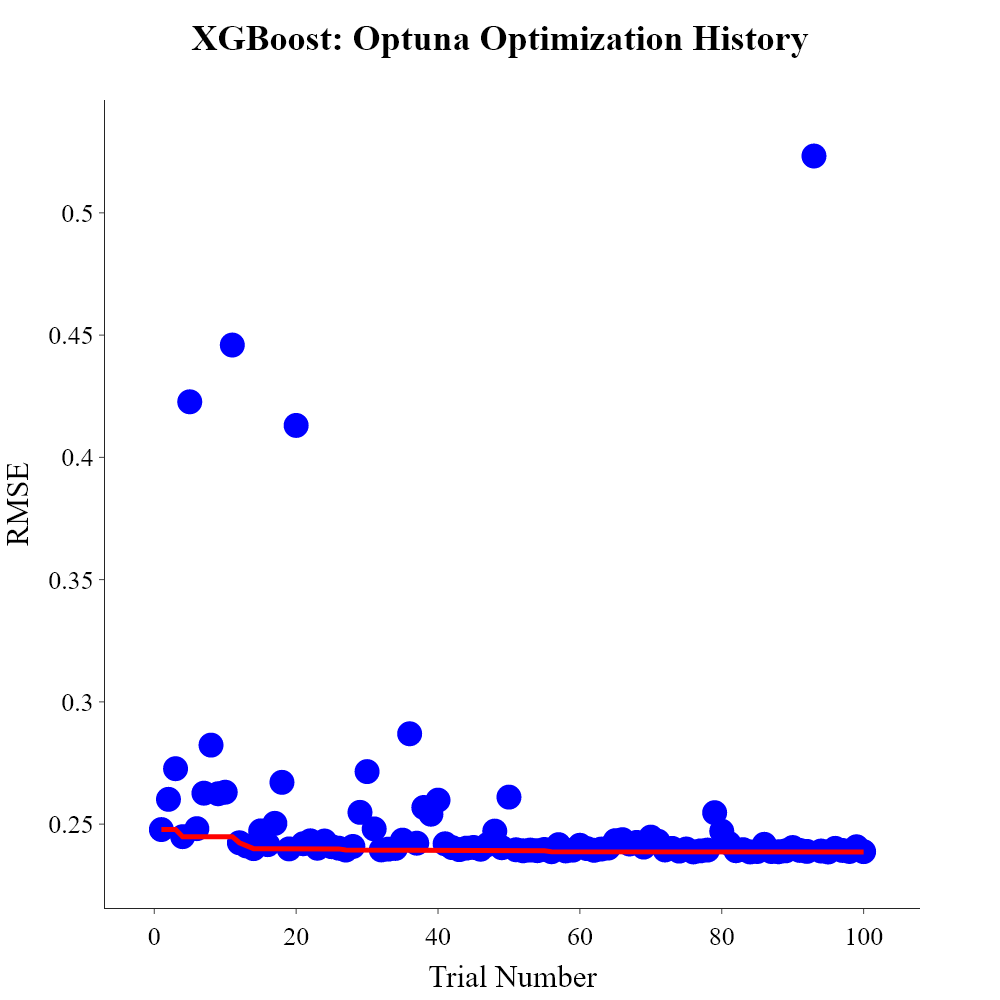

In [20]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

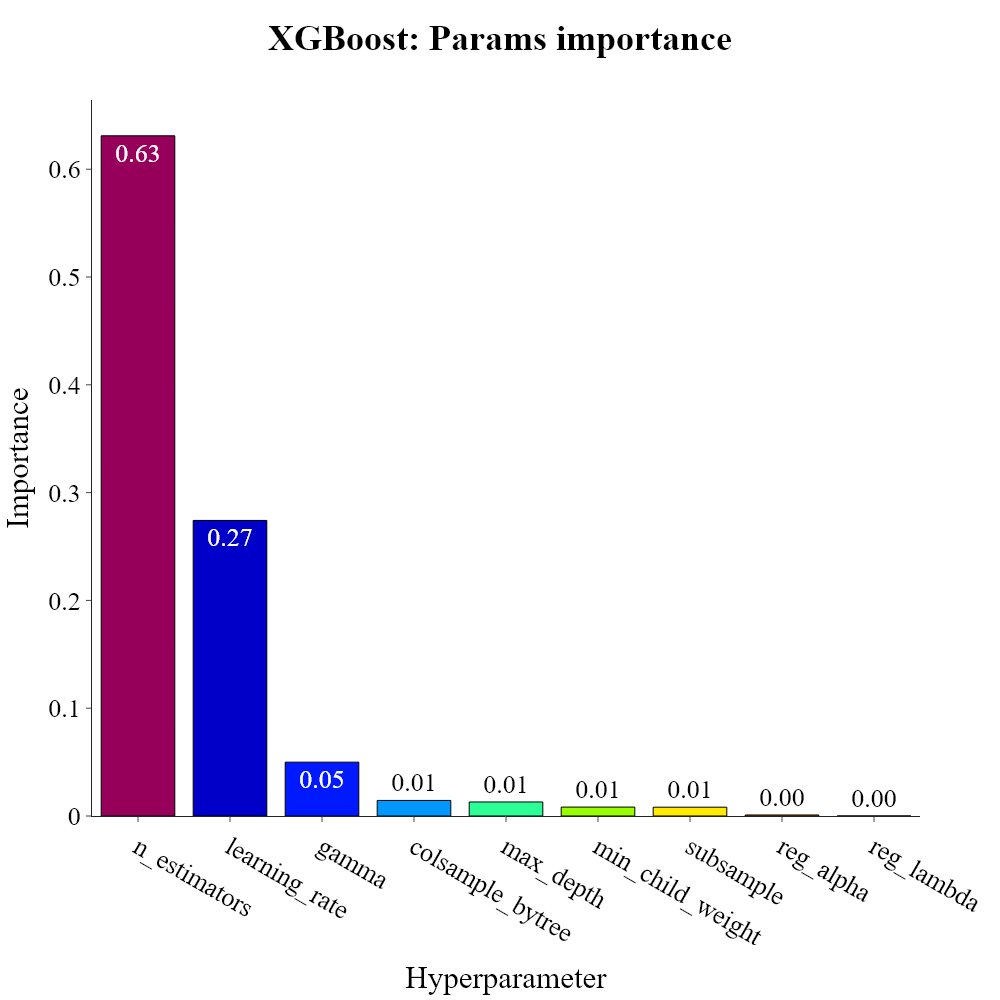

In [21]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [22]:
model = XGBRegressor(**xgb_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.0990 +- 0.0001
Validation RMSE: 0.2317 +- 0.0015


### Histogram-based Gradient Boosting

In [23]:
model = HistGradientBoostingRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "loss": ("constant", ["squared_error"]),
    "categorical_features": ("constant", [categorical_features]),
    "early_stopping": ("constant", [True]),
}
tunable_params_grid = {
    "learning_rate": ("float", [1e-3, 0.3]),
    "max_iter": ("int", [50, 1000]),
    "max_leaf_nodes": ("int", [10, 512]),
    "max_depth": ("int", [3, 30]),
    "max_features": ("float", [0.3, 1.0]),
    "min_samples_leaf": ("int", [20, 300]),
    "l2_regularization": ("float", [1e-3, 30]),
    "max_bins": ("int", [64, 255]),
    "n_iter_no_change": ("int", [10, 50]),
    "validation_fraction": ("float", [0.1, 0.3]),
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
hgbm_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
hgbm_best_params = {**constant_params, **hgbm_best_params}
print(hgbm_best_params)

[I 2025-06-16 10:23:39,524] A new study created in memory with name: Optuna tuning
[I 2025-06-16 10:23:59,133] Trial 0 finished with value: 0.30982398665046407 and parameters: {'learning_rate': 0.005369340441799301, 'max_iter': 554, 'max_leaf_nodes': 106, 'max_depth': 4, 'max_features': 0.7737830722497602, 'min_samples_leaf': 204, 'l2_regularization': 0.7149214935861121, 'max_bins': 174, 'n_iter_no_change': 11, 'validation_fraction': 0.1481564202055472}. Best is trial 0 with value: 0.30982398665046407.
[I 2025-06-16 10:24:26,660] Trial 1 finished with value: 0.25355252519797733 and parameters: {'learning_rate': 0.2200756140551977, 'max_iter': 107, 'max_leaf_nodes': 444, 'max_depth': 27, 'max_features': 0.31907247004783607, 'min_samples_leaf': 203, 'l2_regularization': 0.2952961466414886, 'max_bins': 178, 'n_iter_no_change': 29, 'validation_fraction': 0.13646449311033657}. Best is trial 1 with value: 0.25355252519797733.
[I 2025-06-16 10:26:07,008] Trial 2 finished with value: 0.2605907

{'random_state': 17, 'loss': 'squared_error', 'categorical_features': ['Condition', 'Vehicle_brand', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Colour', 'Origin_country', 'First_registration_year', 'First_registration_month', 'Offer_publication_day', 'Offer_publication_weekday', 'wojewodztwo', 'feature_ABS', 'feature_Central locking', 'feature_Electric front windows', 'feature_Drivers airbag', 'feature_Power steering', 'feature_Passengers airbag', 'feature_Electrically adjustable mirrors', 'feature_Factory radio', 'feature_Immobilizer', 'feature_On-board computer', 'feature_ESP(stabilization of the track)', 'feature_Alloy wheels', 'feature_CD', 'feature_ASR (traction control)', 'feature_Multifunction steering wheel', 'feature_Automatic air conditioning', 'feature_Isofix', 'feature_Front side airbags', 'feature_Fog lights', 'feature_Electric rear windows', 'feature_Cruise control', 'feature_Heated side mirrors', 'feature_Air curtains', 'feature_Rear parking sensors', 'feature_Blueto

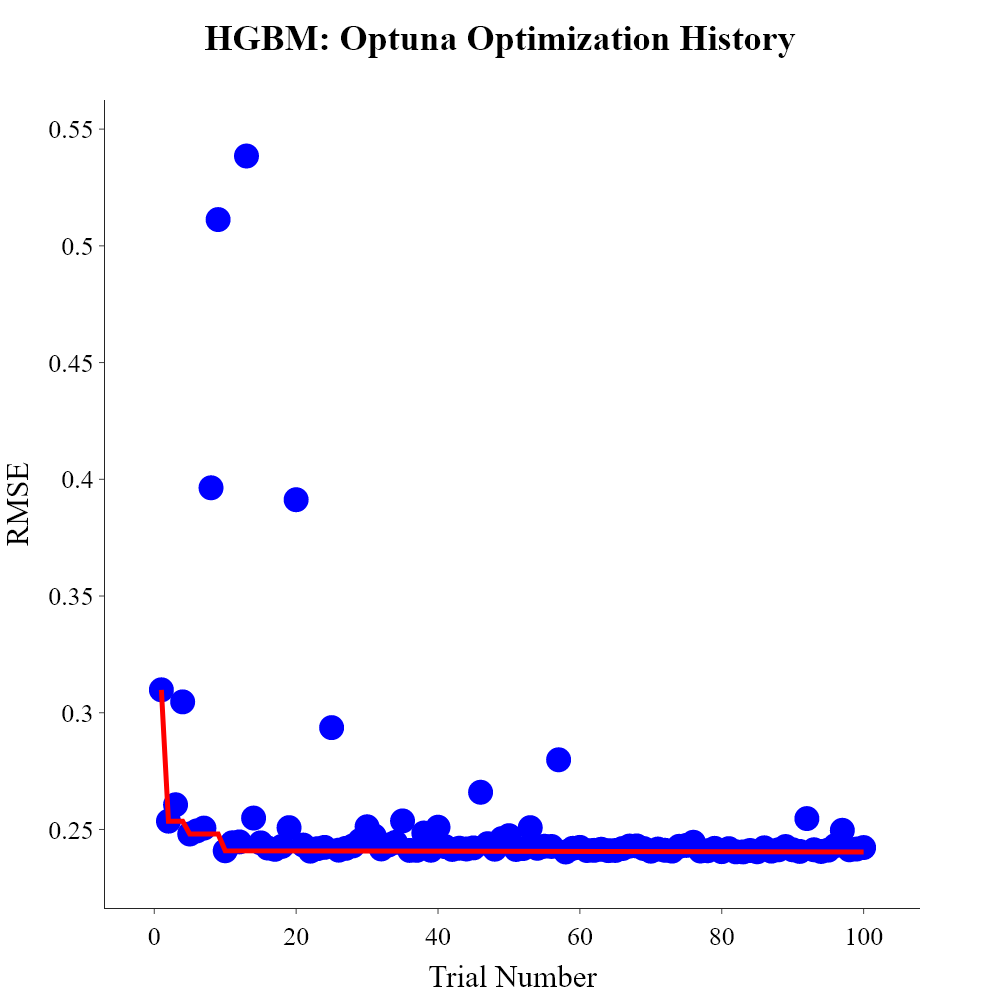

In [24]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

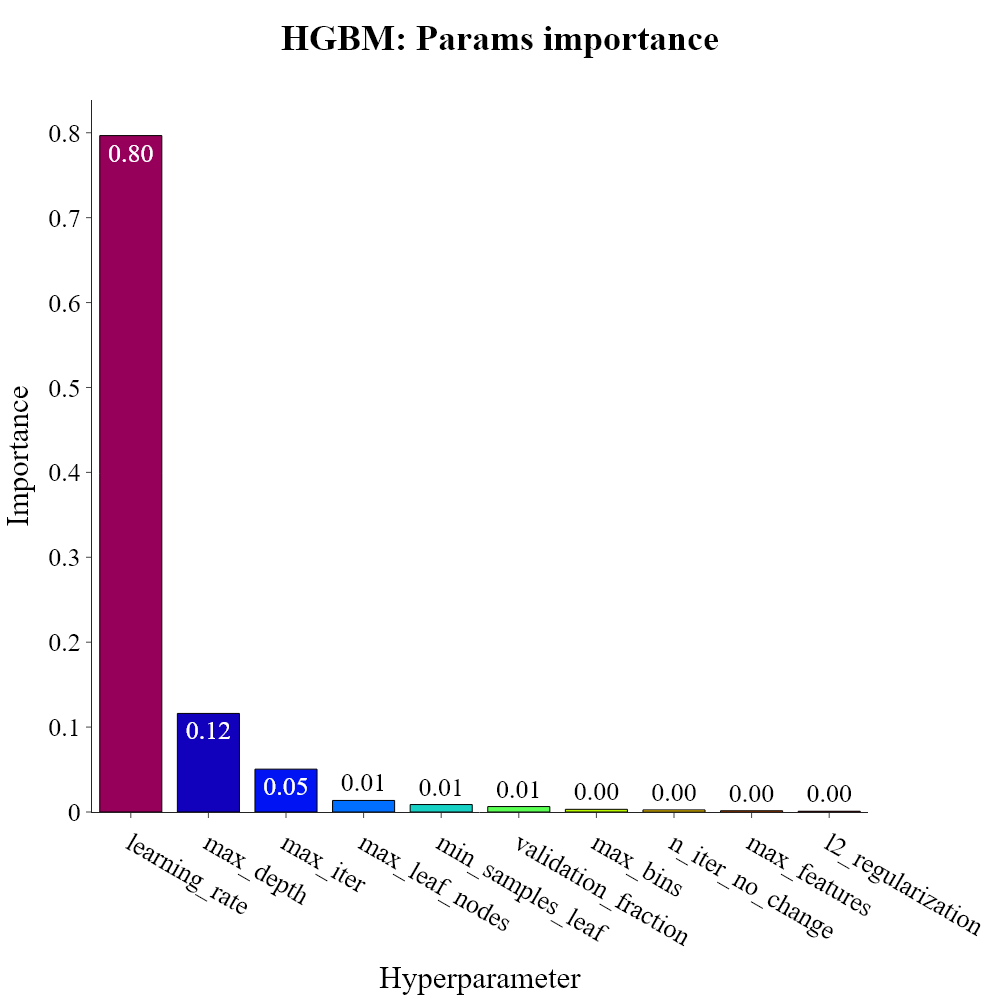

In [25]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [26]:
model = HistGradientBoostingRegressor(**hgbm_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.1271 +- 0.0004
Validation RMSE: 0.2339 +- 0.0016


### Catboost

In [27]:
model = CatBoostRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

constant_params_grid = {
    "random_state": ("constant", [SEED]),
    "verbose": ("constant", [0]),
    "cat_features": ("constant", [categorical_features]),
    "task_type": ("constant", ["GPU"]),
    "loss_function": ("constant", ["RMSE"]),
    "eval_metric": ("constant", ["RMSE"]),
    "early_stopping_rounds": ("constant", [100]),
}
tunable_params_grid = {
    "iterations": ("int", [50, 1000]),
    "learning_rate": ("float", [1e-3, 0.3]),
    "depth": ("int", [3, 10]),
    "l2_leaf_reg": ("float", [1e-3, 30]),
    "random_strength": ("float", [1e-3, 10.0]),
    "bagging_temperature": ("float", [0.3, 1.0]),
    "border_count": ("int", [32, 255]),
    "min_data_in_leaf": ("int", [1, 300]),
}
params_grid = {**constant_params_grid, **tunable_params_grid}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
catboost_best_params = study.best_trial.params
constant_params = {k: v[1][0] for k, v in constant_params_grid.items()}
catboost_best_params = {**constant_params, **catboost_best_params}
print(catboost_best_params)

[I 2025-06-16 16:06:33,312] A new study created in memory with name: Optuna tuning
[I 2025-06-16 16:07:02,278] Trial 0 finished with value: 0.3012385362190002 and parameters: {'iterations': 330, 'learning_rate': 0.0206218550445619, 'depth': 4, 'l2_leaf_reg': 0.00201371561093265, 'random_strength': 1.4058592411732862, 'bagging_temperature': 0.6611562428979949, 'border_count': 174, 'min_data_in_leaf': 173}. Best is trial 0 with value: 0.3012385362190002.
[I 2025-06-16 16:07:12,754] Trial 1 finished with value: 0.5987164893439016 and parameters: {'iterations': 87, 'learning_rate': 0.007697464327022002, 'depth': 10, 'l2_leaf_reg': 0.0018570658959306857, 'random_strength': 2.8586988975615437, 'bagging_temperature': 0.8626563515456908, 'border_count': 43, 'min_data_in_leaf': 196}. Best is trial 0 with value: 0.3012385362190002.
[I 2025-06-16 16:08:21,446] Trial 2 finished with value: 0.26322993269620126 and parameters: {'iterations': 574, 'learning_rate': 0.03020736057097153, 'depth': 6, 'l2

{'random_state': 17, 'verbose': 0, 'cat_features': ['Condition', 'Vehicle_brand', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Colour', 'Origin_country', 'First_registration_year', 'First_registration_month', 'Offer_publication_day', 'Offer_publication_weekday', 'wojewodztwo', 'feature_ABS', 'feature_Central locking', 'feature_Electric front windows', 'feature_Drivers airbag', 'feature_Power steering', 'feature_Passengers airbag', 'feature_Electrically adjustable mirrors', 'feature_Factory radio', 'feature_Immobilizer', 'feature_On-board computer', 'feature_ESP(stabilization of the track)', 'feature_Alloy wheels', 'feature_CD', 'feature_ASR (traction control)', 'feature_Multifunction steering wheel', 'feature_Automatic air conditioning', 'feature_Isofix', 'feature_Front side airbags', 'feature_Fog lights', 'feature_Electric rear windows', 'feature_Cruise control', 'feature_Heated side mirrors', 'feature_Air curtains', 'feature_Rear parking sensors', 'feature_Bluetooth', 'feature_Rain

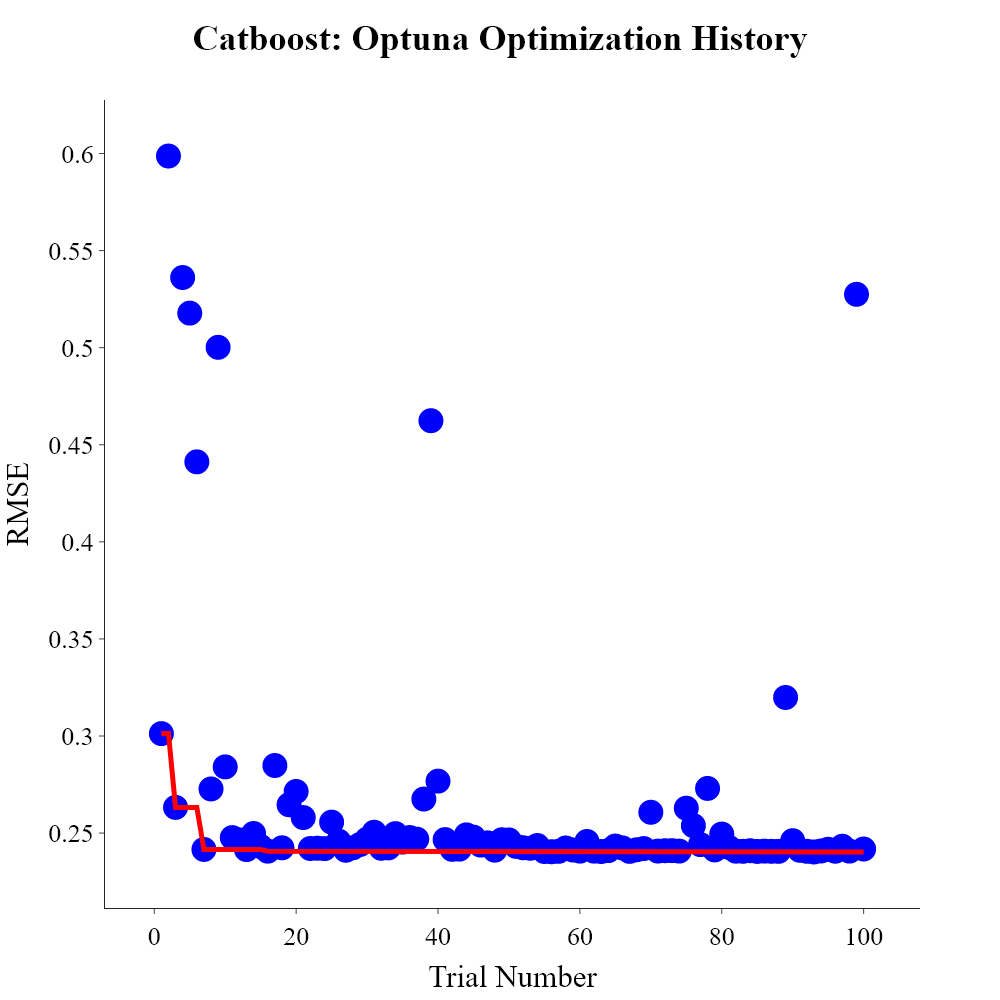

In [28]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>Catboost: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

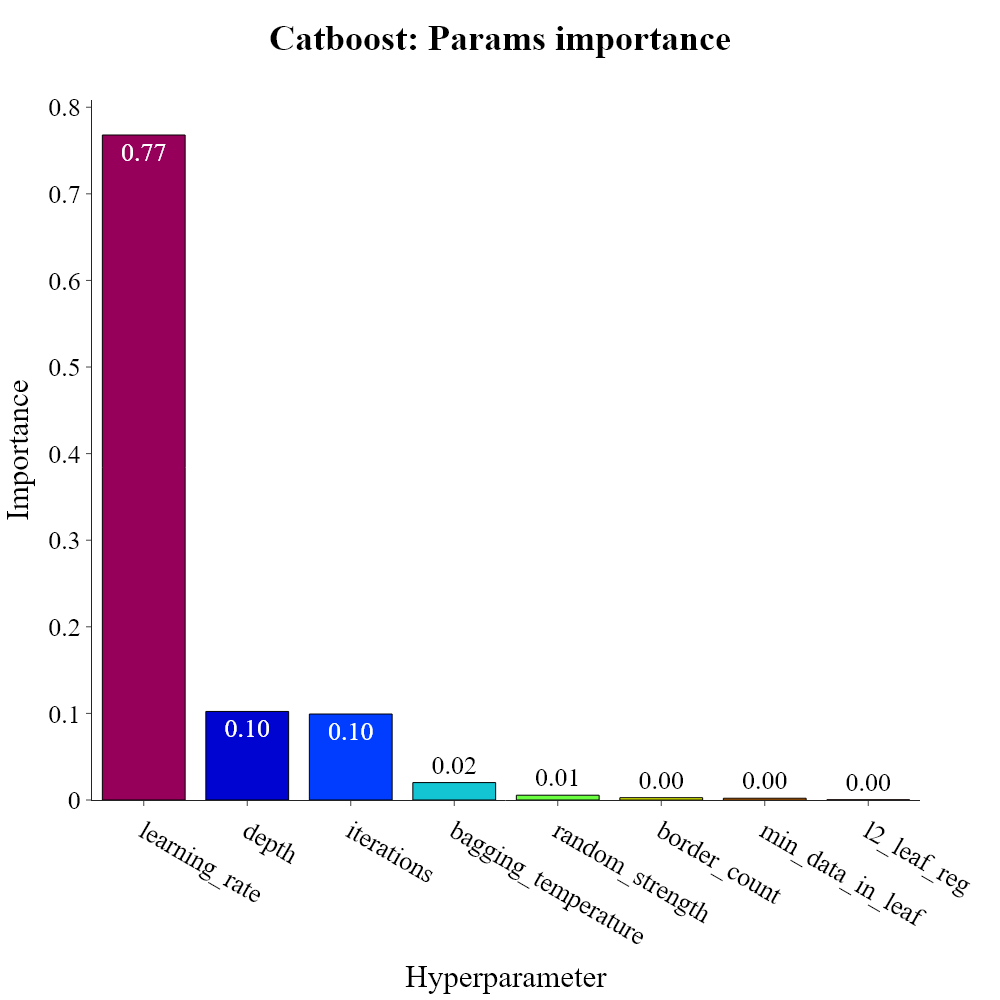

In [29]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>Catboost: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [30]:
model = CatBoostRegressor(**catboost_best_params)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.1742 +- 0.0008
Validation RMSE: 0.2349 +- 0.0019


## Ensemble weight

In [32]:
estimators = [
    LGBMRegressor(**lgbm_best_params),
    XGBRegressor(**xgb_best_params),
    HistGradientBoostingRegressor(**hgbm_best_params),
    CatBoostRegressor(**catboost_best_params)
]

ensemble_weights_tuner = EnsembleWeightTunerCV(
    estimators = estimators,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS*2,
    seed=SEED
)
ensemble_weights_tuner.tune(train_data[independent_features], train_data[target_feature])
best_weights = ensemble_weights_tuner.best_weights
for i, estimator in enumerate(ensemble_weights_tuner.estimators):
    print(f"Estimator {i}: {estimator.__class__.__name__}, Weight: {best_weights[i]:.4f}")

[I 2025-06-16 20:39:25,875] A new study created in memory with name: Weight Tuning Study
[I 2025-06-16 20:39:25,880] Trial 0 finished with value: 0.2301863723149753 and parameters: {'w0': 0.2987717026333675, 'w1': 0.5299750204931882, 'w2': 0.19769037120854496, 'w3': 0.07654235102746554}. Best is trial 0 with value: 0.2301863723149753.
[I 2025-06-16 20:39:25,884] Trial 1 finished with value: 0.22989621587274595 and parameters: {'w0': 0.7812457507999151, 'w1': 0.6532068513403384, 'w2': 0.6347704781227631, 'w3': 0.5740908358779733}. Best is trial 1 with value: 0.22989621587274595.
[I 2025-06-16 20:39:25,890] Trial 2 finished with value: 0.23124076198704757 and parameters: {'w0': 0.04828165786508915, 'w1': 0.3606573323938779, 'w2': 0.9367695230820394, 'w3': 0.06884378670907763}. Best is trial 1 with value: 0.22989621587274595.
[I 2025-06-16 20:39:25,893] Trial 3 finished with value: 0.2299435364708658 and parameters: {'w0': 0.8567612614752868, 'w1': 0.8697447156250696, 'w2': 0.060169792308

Estimator 0: LGBMRegressor, Weight: 0.1204
Estimator 1: XGBRegressor, Weight: 0.4169
Estimator 2: HistGradientBoostingRegressor, Weight: 0.1558
Estimator 3: CatBoostRegressor, Weight: 0.3070


# Evaluation

In [33]:
class EnsembleModel(BaseEstimator, RegressorMixin):
    def __init__(self, estimators, weights):
        self.estimators = estimators
        self.weights = weights

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series, eval_set: tuple[pd.DataFrame, pd.Series], verbose: bool = False, sample_weight: pd.Series = None):
        for estimator in self.estimators:
            sig = signature(estimator.fit)
            fit_params = {}
            if "eval_set" in sig.parameters:
                fit_params["eval_set"] = eval_set
            if "verbose" in sig.parameters:
                fit_params["verbose"] = False
            if "X_val" and "y_val" in sig.parameters:
                fit_params["X_val"] = eval_set[0][0]
                fit_params["y_val"] = eval_set[0][1]
            #Można spróbować dodać sample_weight do fit_params i sprawdzić czy będzie lepiej
            # if "sample_weight" in sig.parameters:
            #     fit_params["sample_weight"] = sample_weight
            estimator.fit(X_train, y_train, **fit_params)
        return self

    def predict(self, X):
        preds = np.array([estimator.predict(X) for estimator in self.estimators])
        weighted_preds = np.average(preds, axis=0, weights=self.weights)
        return weighted_preds

final_model = EnsembleModel(estimators=ensemble_weights_tuner.estimators, weights=ensemble_weights_tuner.best_weights)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], final_model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSE: 0.1308 +- 0.0007
Validation RMSE: 0.2299 +- 0.0016


In [34]:
final_model.fit(train_data[independent_features], train_data[target_feature], eval_set=[(test_data[independent_features], test_data[target_feature])], verbose=False)

y_train = train_data[target_feature]
y_train_pred = final_model.predict(train_data[independent_features])

y_test = test_data[target_feature]
y_test_pred = final_model.predict(test_data[independent_features])

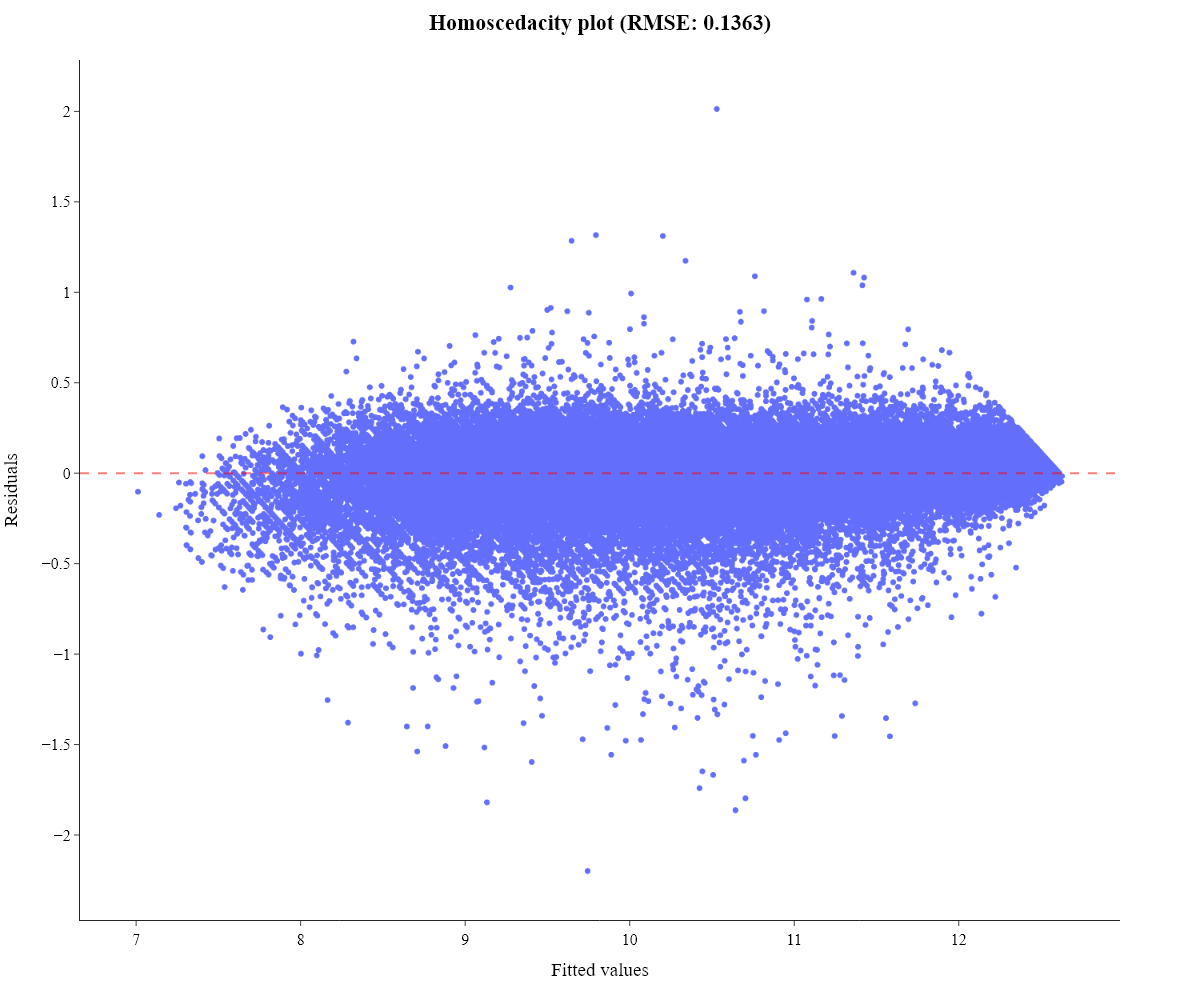

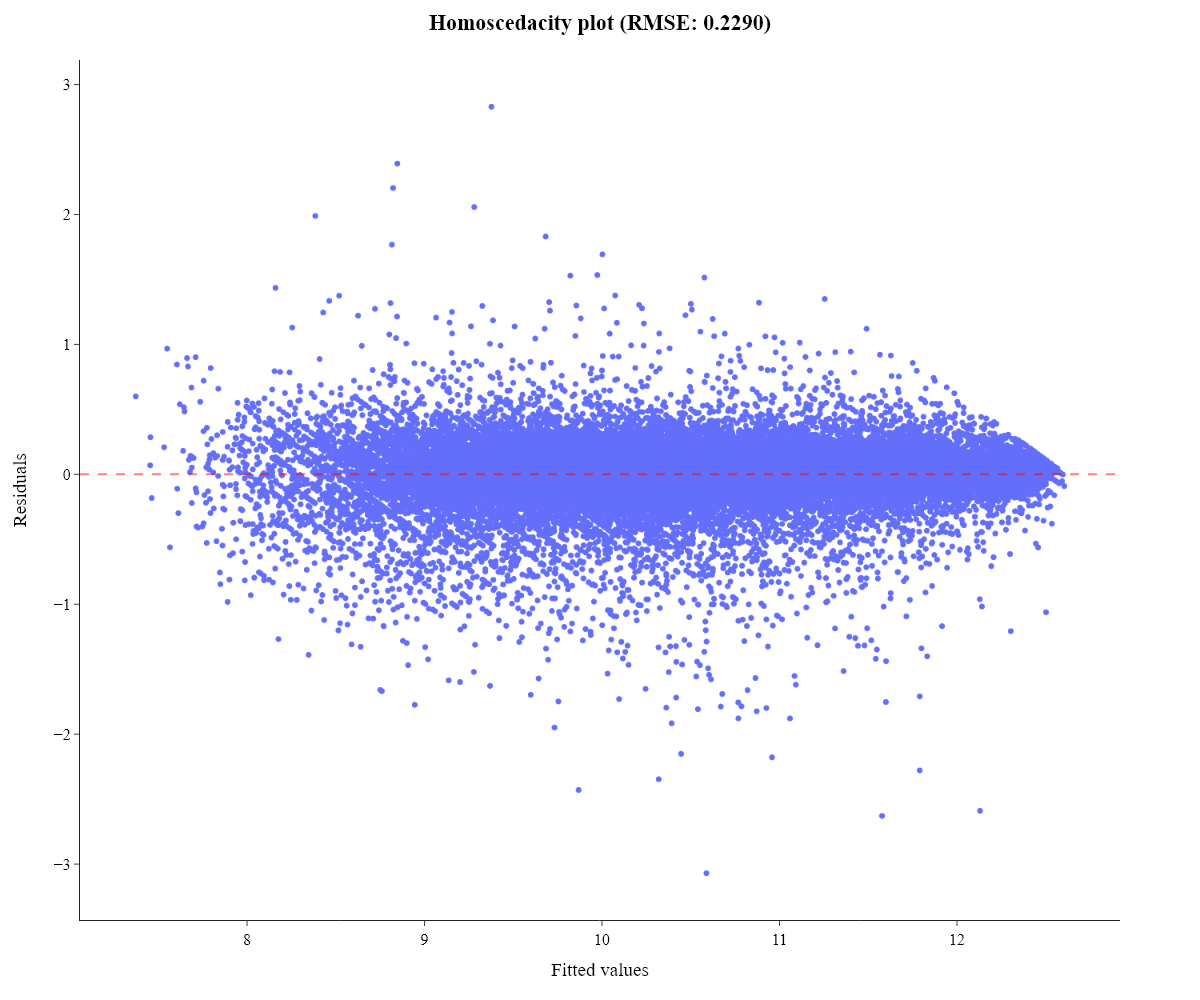

In [39]:
plots.homoscedacity_plot(y_train, y_train_pred, metric=compare_metric_name)
plots.homoscedacity_plot(y_test, y_test_pred, metric=compare_metric_name)

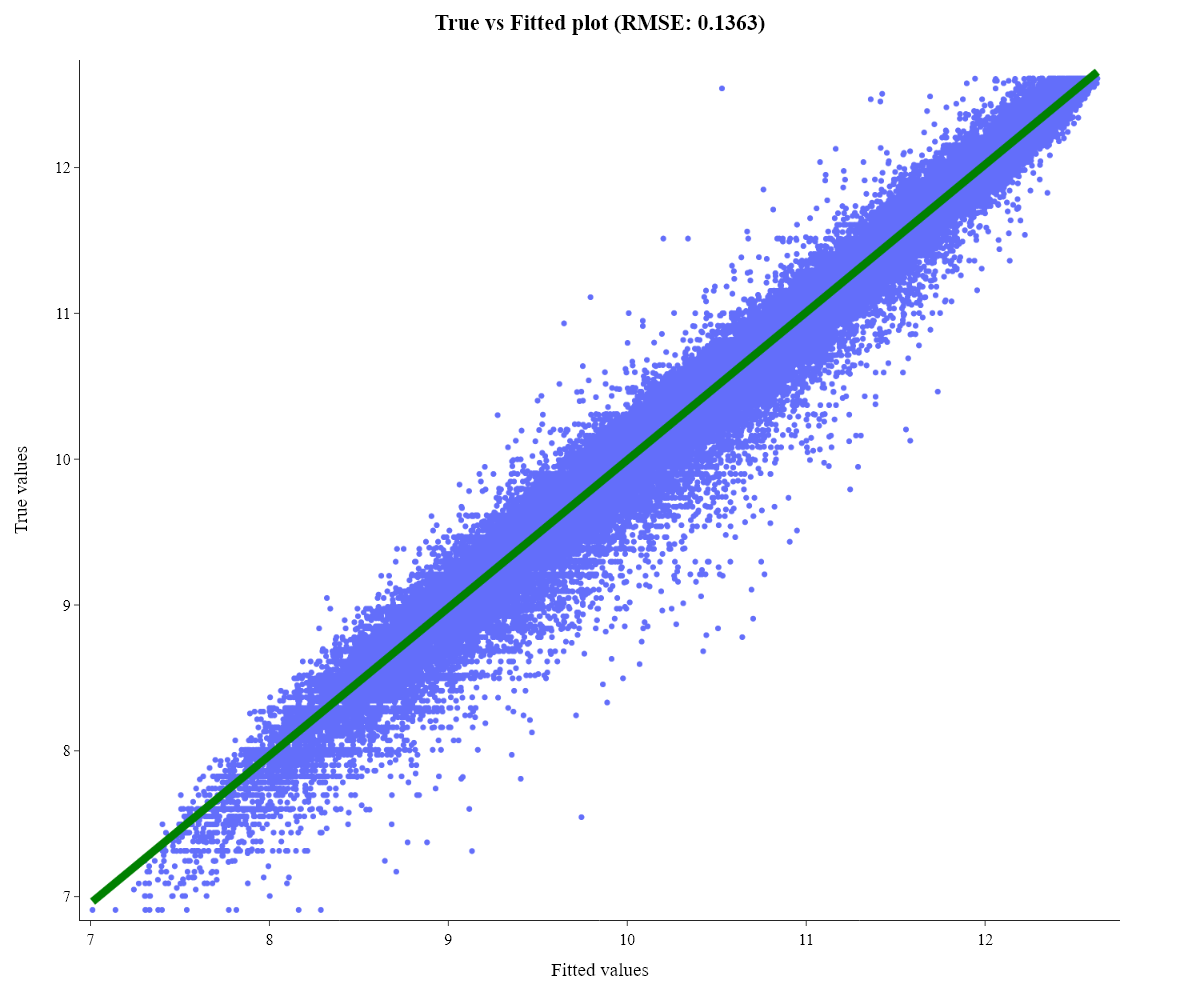

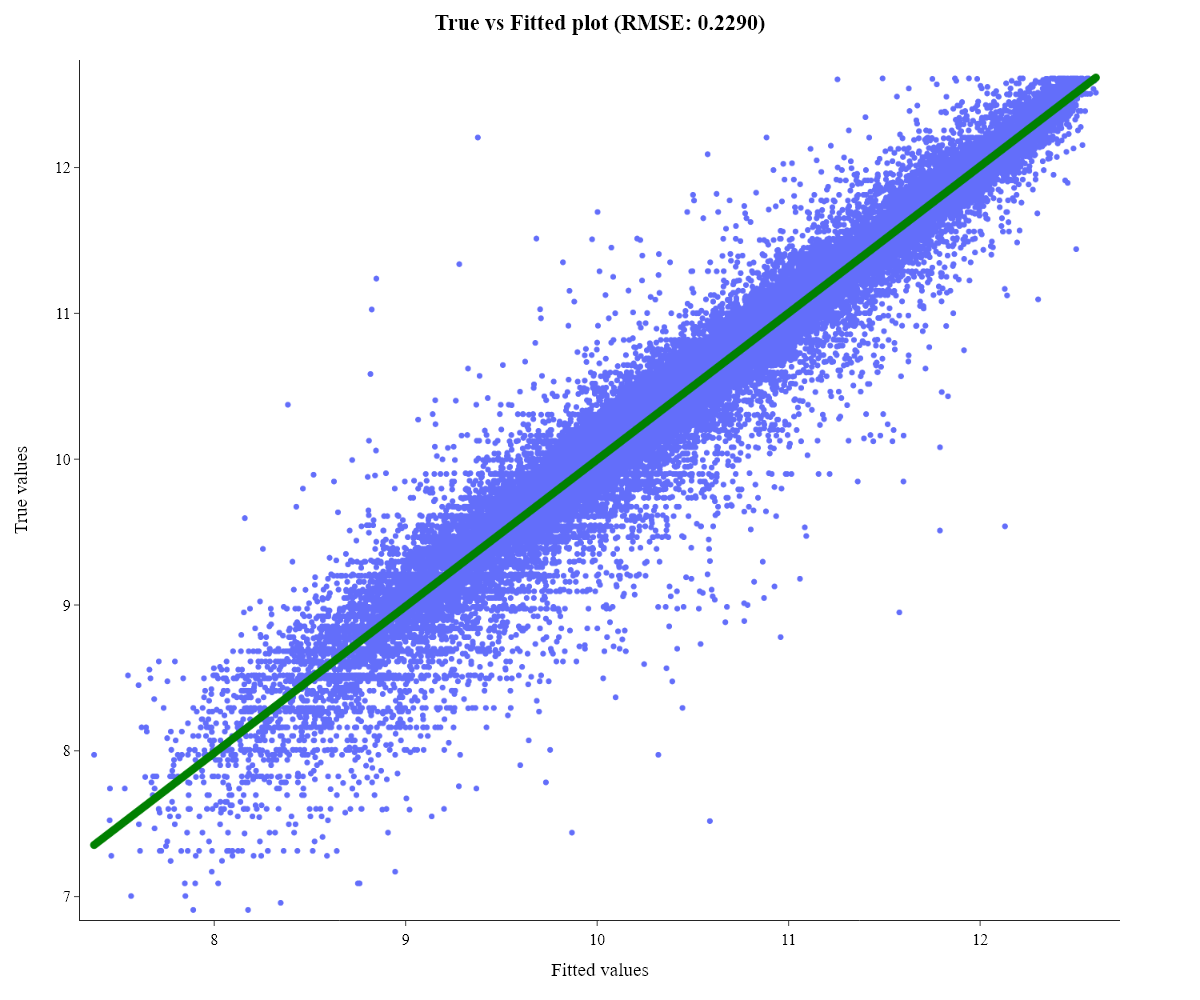

In [40]:
plots.true_vs_fitted_plot(y_train, y_train_pred, metric=compare_metric_name)
plots.true_vs_fitted_plot(y_test, y_test_pred, metric=compare_metric_name)

In [46]:
def regression_results(y_train_true: pd.Series, y_train_pred: np.ndarray, y_test_true: pd.Series, y_test_pred: np.ndarray):
    """
    Generates a styled DataFrame with regression results including MAE, MSE, RMSE and R2 scores for both training and testing datasets.
    
    Args:
        y_train_true (pd.Series): True values for the training set.
        y_train_pred (np.ndarray): Predicted values for the training set.
        y_test_true (pd.Series): True values for the testing set.
        y_test_pred (np.ndarray): Predicted values for the testing set.
    
    Returns:
        pd.DataFrame: A styled DataFrame containing the regression results.
    """
    metrics = {
        "MAE": [mean_absolute_error(y_train_true, y_train_pred), mean_absolute_error(y_test_true, y_test_pred)],
        "MSE": [mean_squared_error(y_train_true, y_train_pred), mean_squared_error(y_test_true, y_test_pred)],
        "RMSE": [root_mean_squared_error(y_train_true, y_train_pred), root_mean_squared_error(y_test_true, y_test_pred)],
        "R2": [r2_score(y_train_true, y_train_pred), r2_score(y_test_true, y_test_pred)]
    }

    df = pd.DataFrame(metrics, index=["Train", "Test"])
    styled_df = (
        df
        .style
        .set_caption("📊 Regression Results")
        .format({
            'MAE': '{:.4f}',
            'MSE': '{:.4f}',
            'RMSE': '{:.4f}',
            'R2': '{:.4f}'
        })
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'), ('border', '1px solid #ddd')]}])
    )
    return styled_df

regression_results(y_train, y_train_pred, y_test, y_test_pred)

,MAE,MSE,RMSE,R2
Train,0.0920,0.0186,0.1363,0.9810
Test,0.1462,0.0524,0.2290,0.9465


In [71]:
import shap
# SHAP does not support direct explanation of custom ensemble wrappers.
# Instead, use one of the underlying models, e.g., the best LightGBM model:
for estimator in ensemble_weights_tuner.estimators:
    if isinstance(estimator, LGBMRegressor):
        continue
    explainer = shap.Explainer(estimator, train_data[independent_features])
    shap_values = explainer(test_data[independent_features], check_additivity=False)
    shap.summary_plot(shap_values, test_data[independent_features], plot_type="bar", show=False)

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5911551120876357, device=None,
             early_stopping_rounds=100, enable_categorical=True,
             eval_metric='rmse', feature_types=None, feature_weights=None,
             gamma=0.0037807720517796487, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.019690041086518867, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=16, max_leaves=None,
             min_child_weight=28, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=835, n_jobs=-1,
             num_parallel_tree=None, ...)

In [87]:
overestimated = y_test_pred > y_test
#Get top 10 of overestimated predictions
top_overestimated_indices = np.argsort(y_test_pred[overestimated])[-10:]

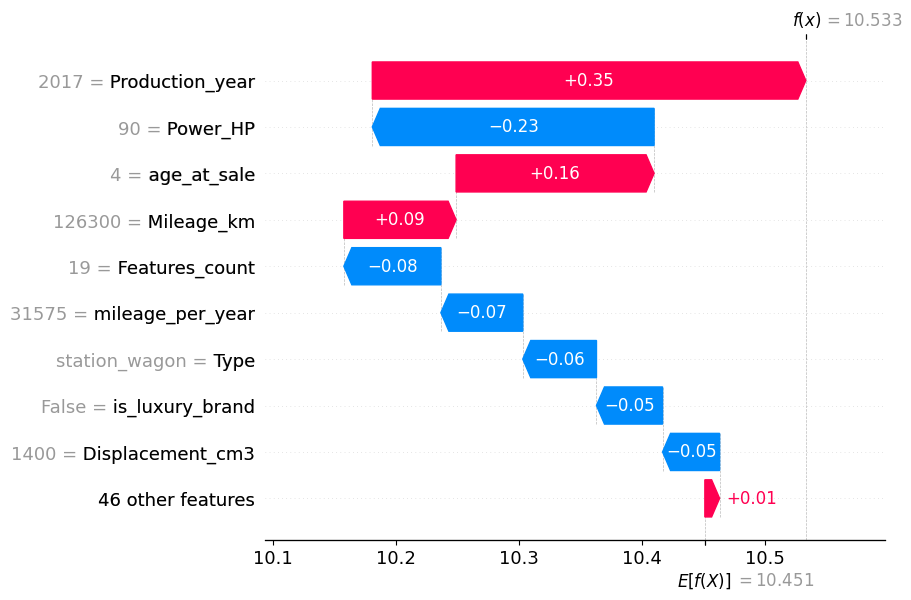

<Figure size 640x480 with 0 Axes>

In [89]:
%matplotlib inline
import matplotlib.pyplot as plt
shap.plots.waterfall(shap_values[top_overestimated_indices[0]])
plt.show()
plt.clf()

In [12]:
model.fit(train_data[independent_features], train_data[target_feature], eval_set=[(test_data[independent_features], test_data[target_feature])], verbose=False)

y_train = train_data[target_feature]
y_train_pred = model.predict(train_data[independent_features])

y_test = test_data[target_feature]
y_test_pred = model.predict(test_data[independent_features])

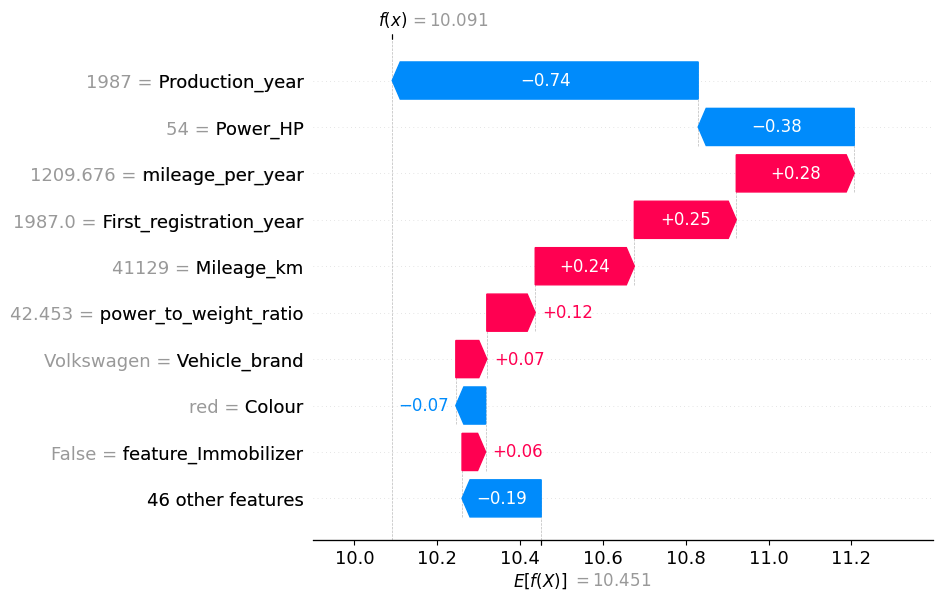

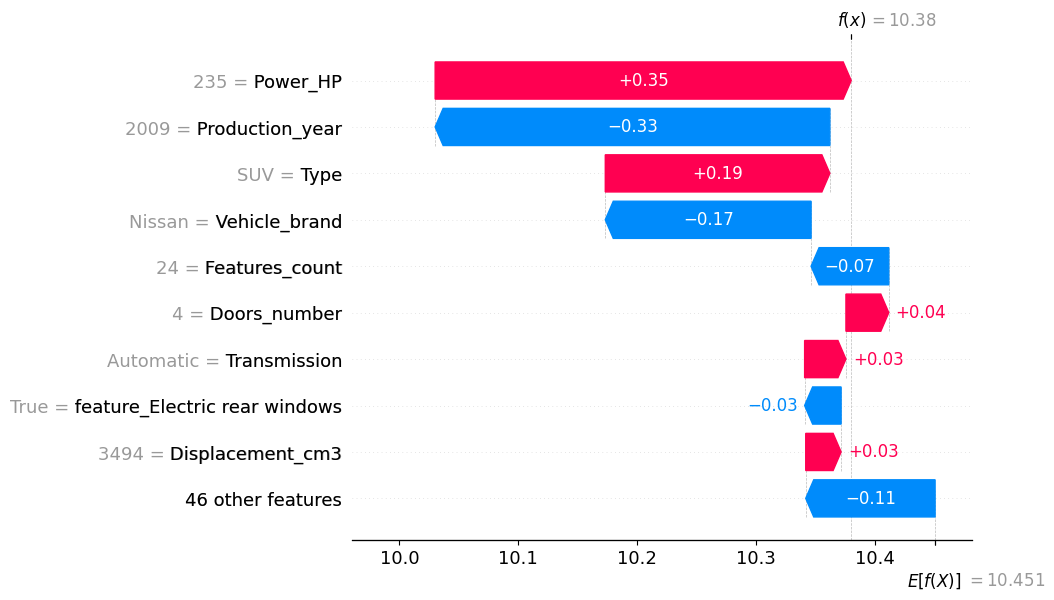

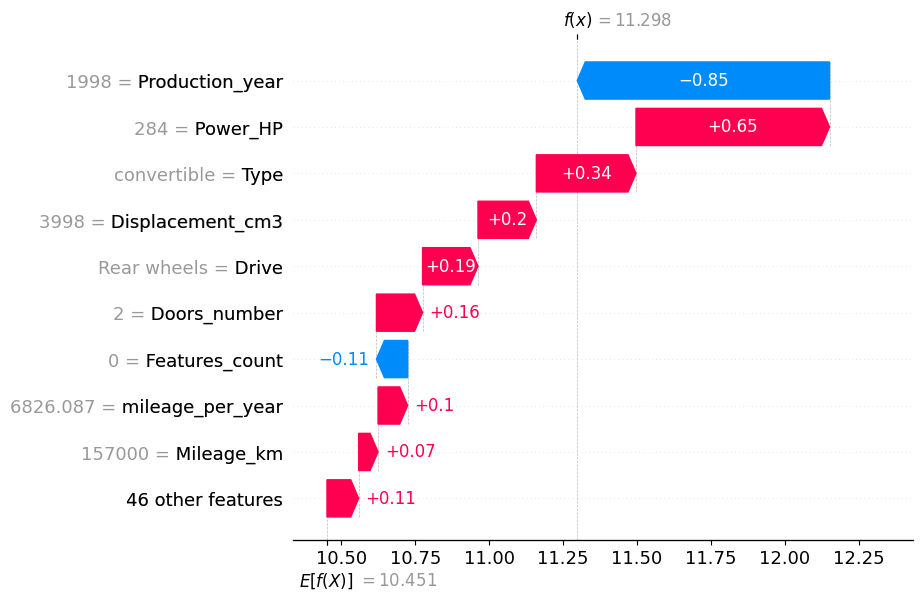

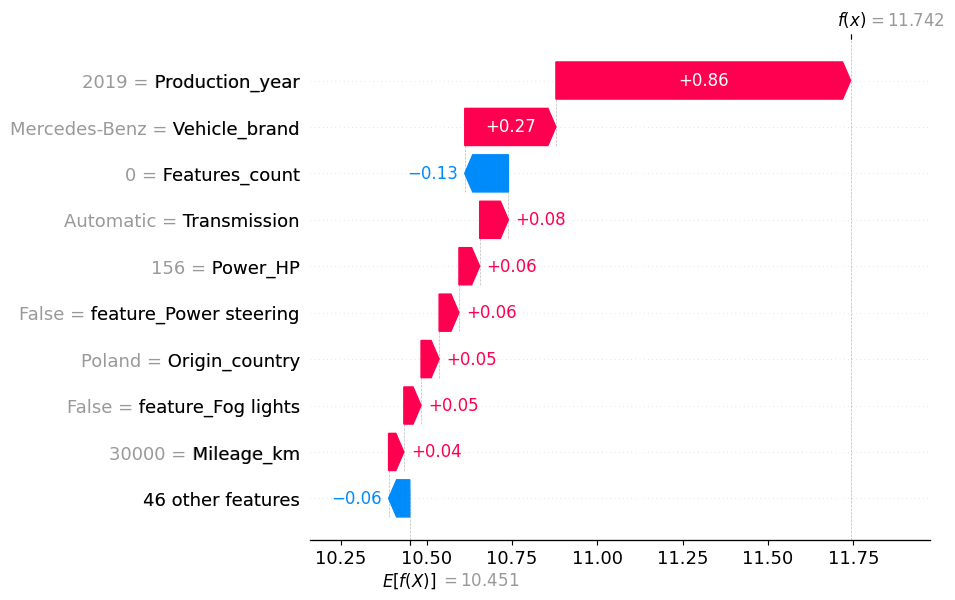

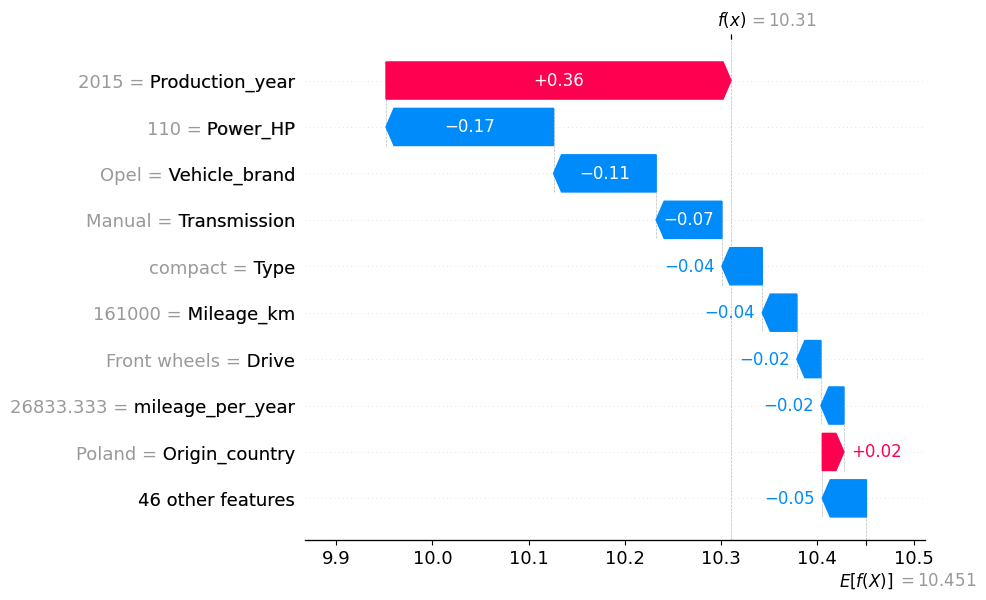

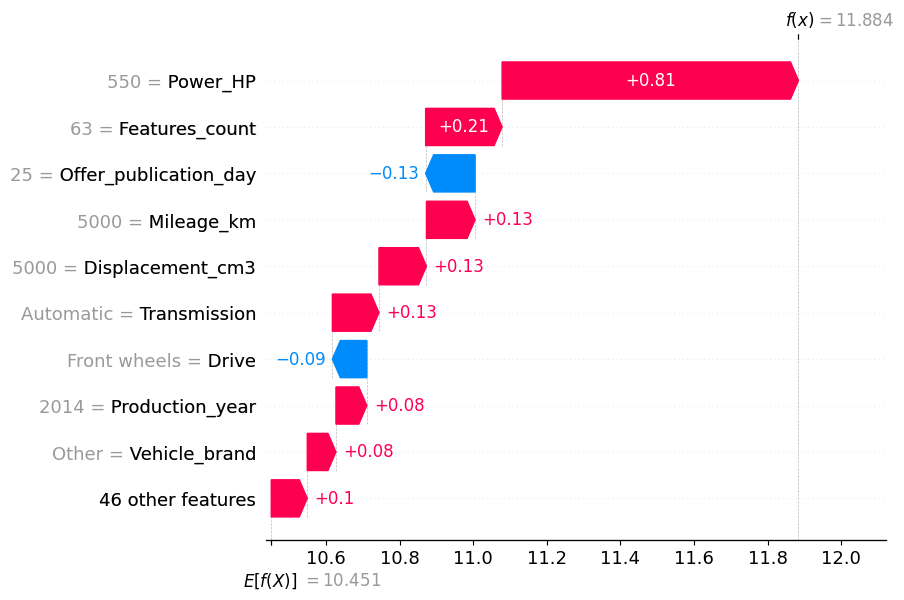

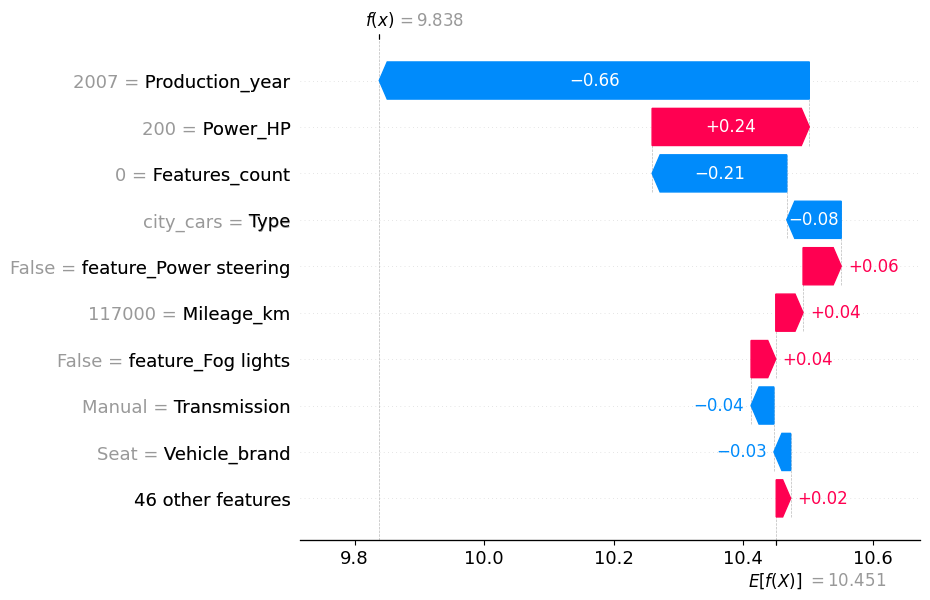

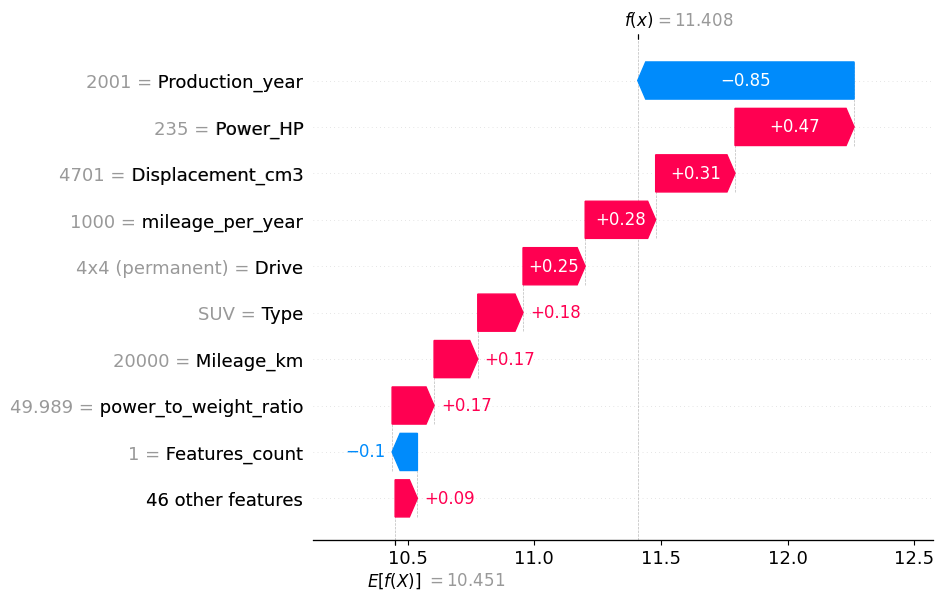

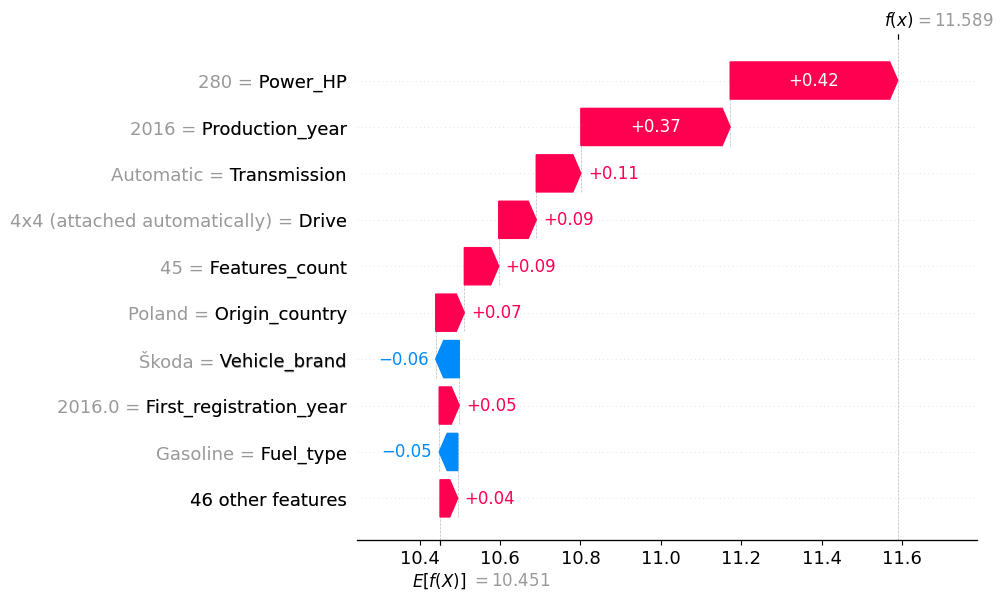

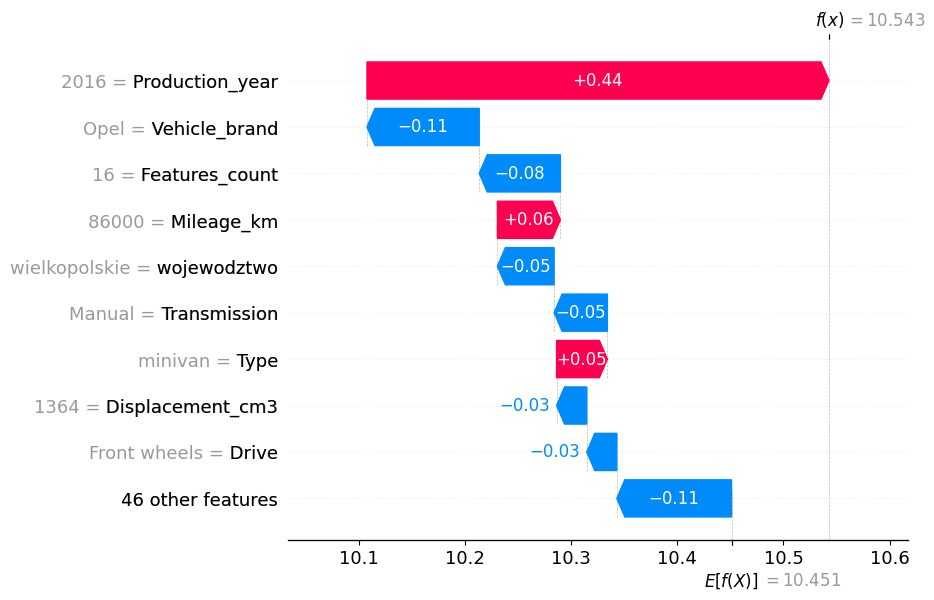

In [19]:
import shap
import matplotlib.pyplot as plt
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer(test_data[independent_features], check_additivity=False)

residuals = y_test - y_test_pred
# Get top 10 overestimated predictions (where prediction > true value)
overestimated = y_test_pred > y_test
top_overestimated_indices = np.argsort(y_test_pred[overestimated] - y_test[overestimated])[-10:]
overestimated_indices = y_test[overestimated].index[top_overestimated_indices]

for i in overestimated_indices:
    shap.plots.waterfall(shap_values[i])
    plt.show()
    plt.clf()

Index: 33660, True value: 8.0064, Predicted value: 10.0913, Residual: 2.0849


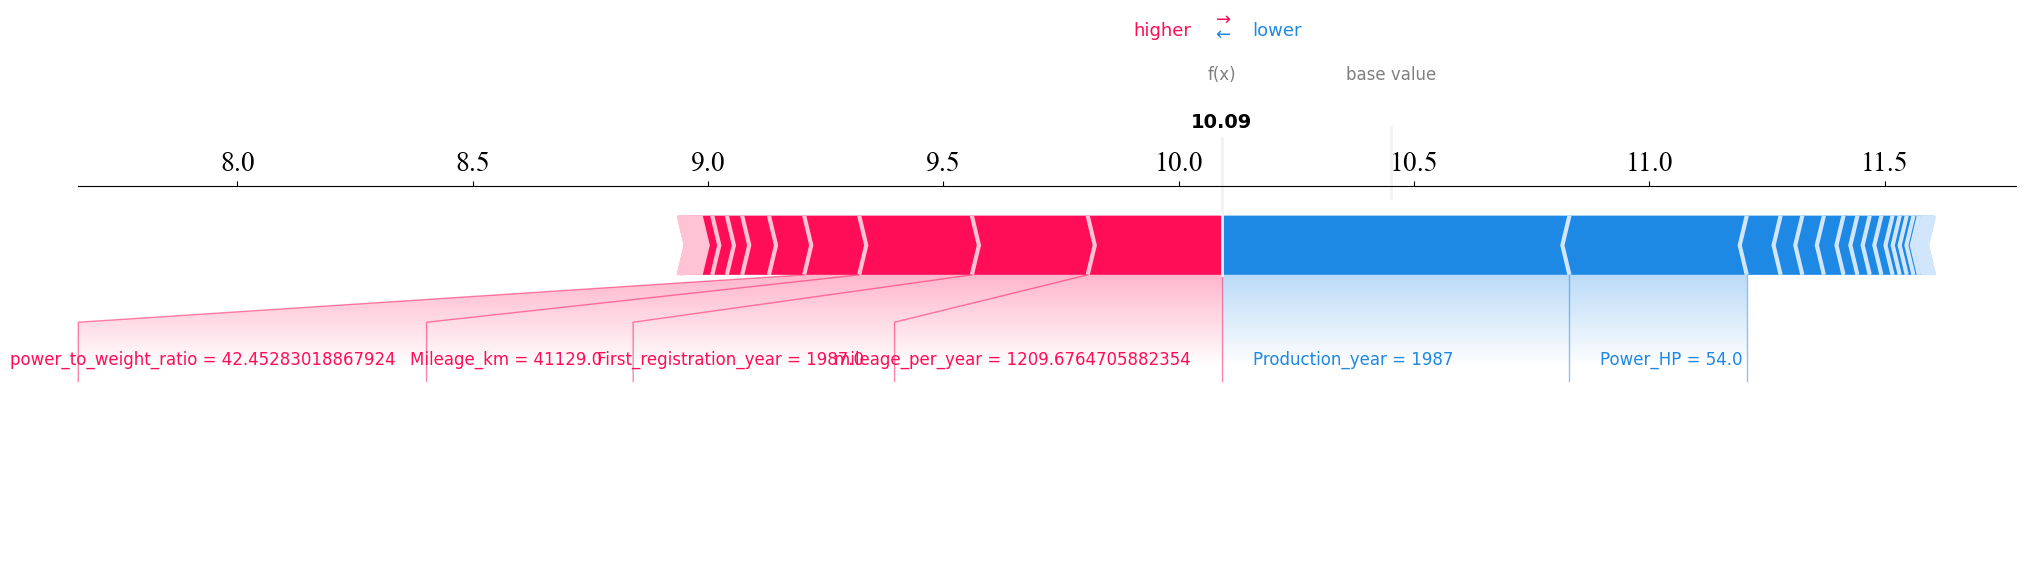

Index: 13589, True value: 8.2943, Predicted value: 10.3804, Residual: 2.0861


<Figure size 640x480 with 0 Axes>

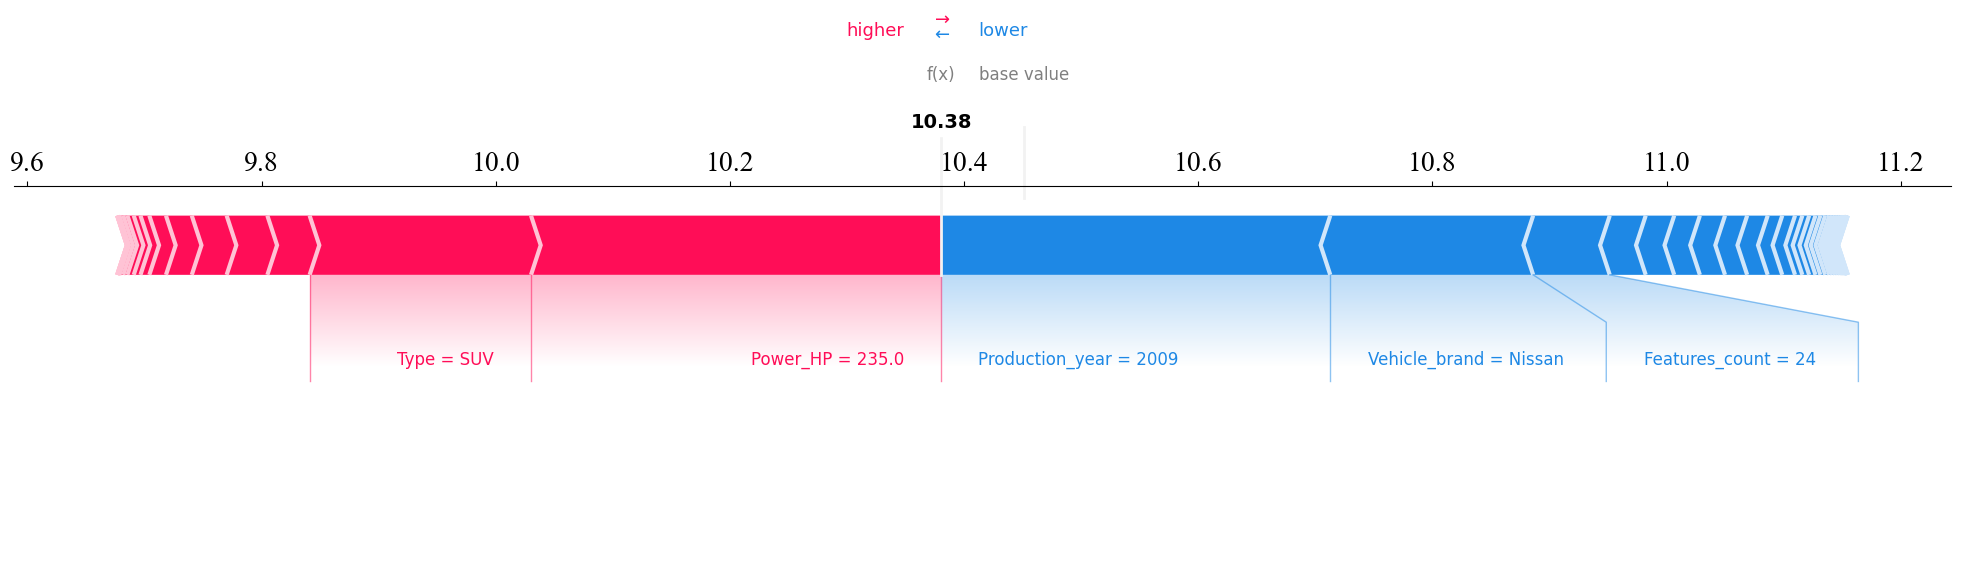

Index: 36789, True value: 9.1051, Predicted value: 11.2981, Residual: 2.1930


<Figure size 640x480 with 0 Axes>

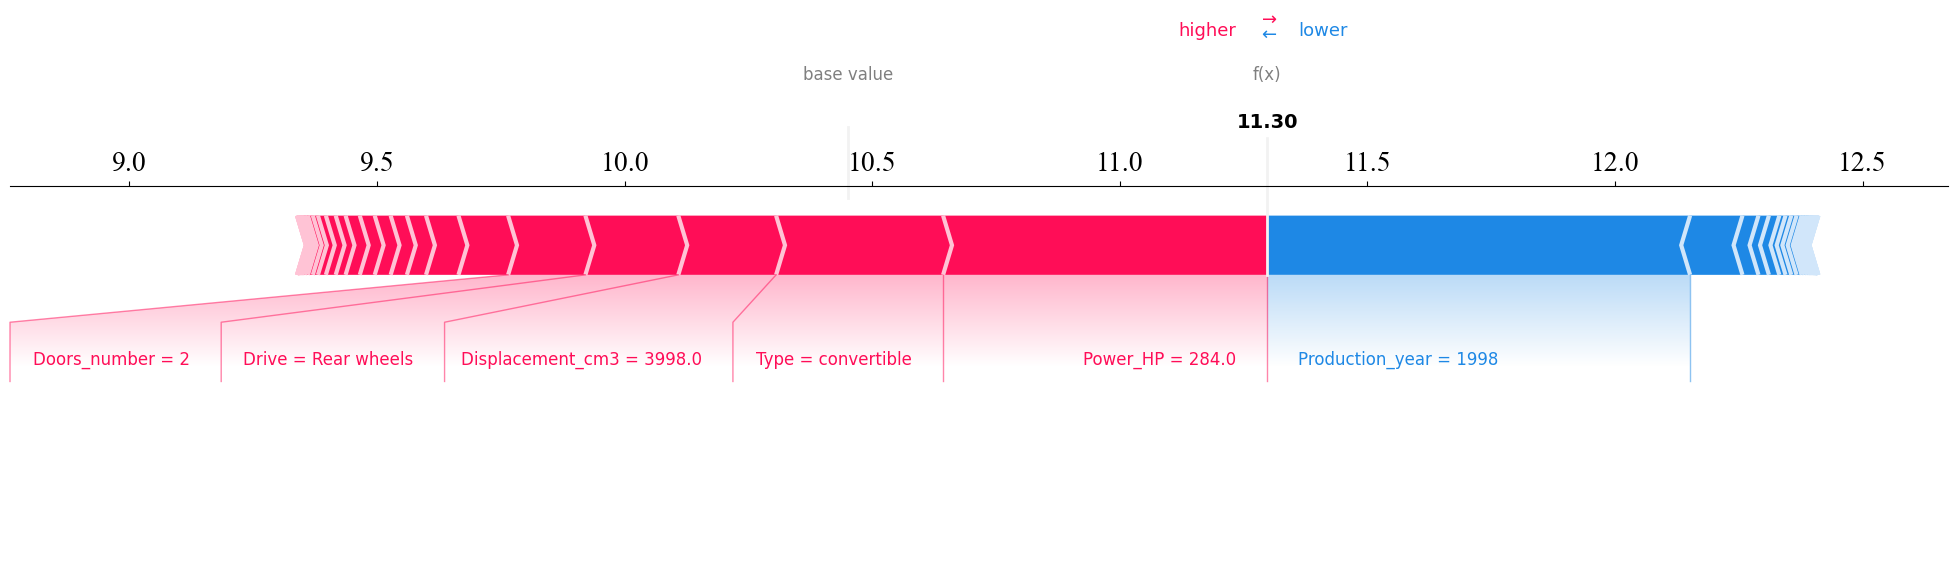

Index: 16269, True value: 9.5105, Predicted value: 11.7415, Residual: 2.2310


<Figure size 640x480 with 0 Axes>

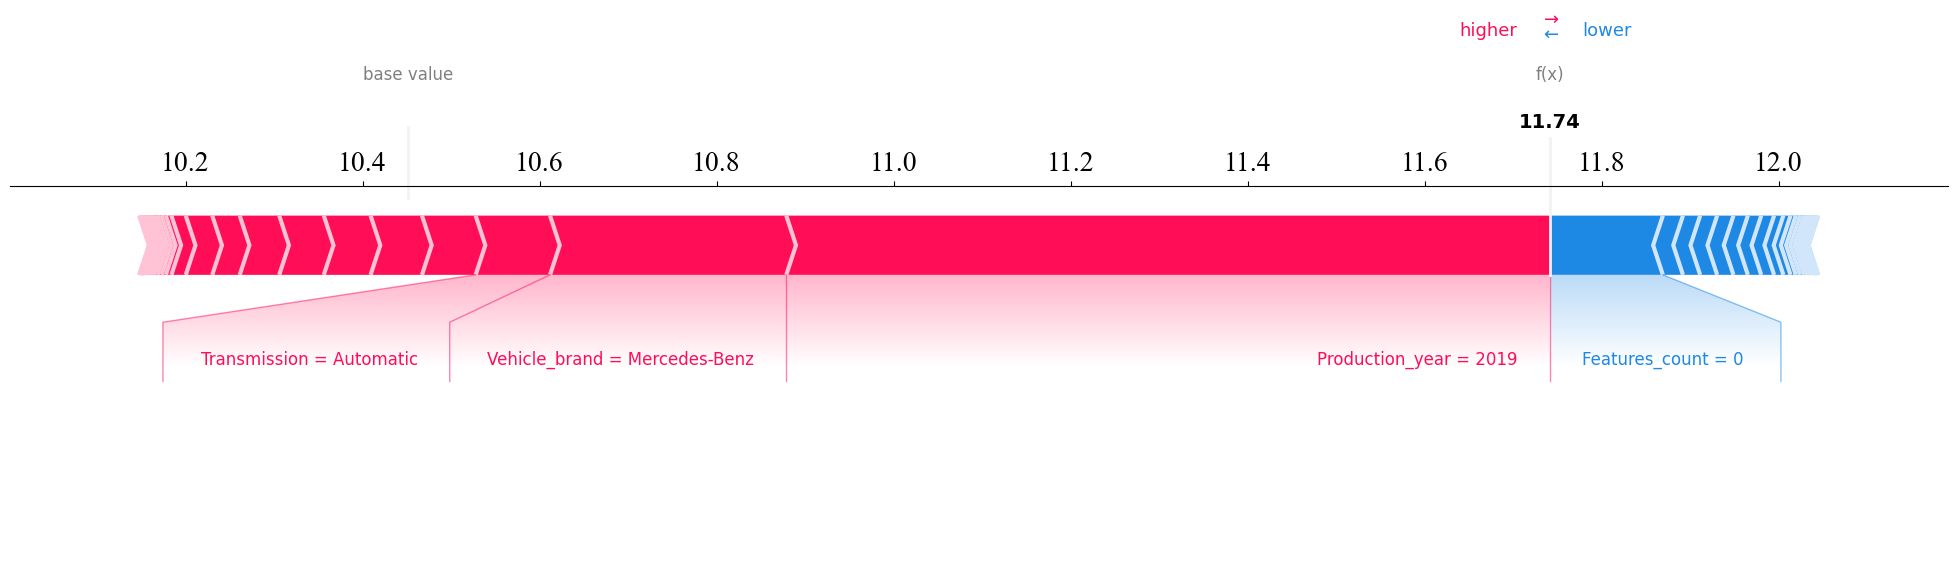

Index: 5692, True value: 7.9728, Predicted value: 10.3103, Residual: 2.3375


<Figure size 640x480 with 0 Axes>

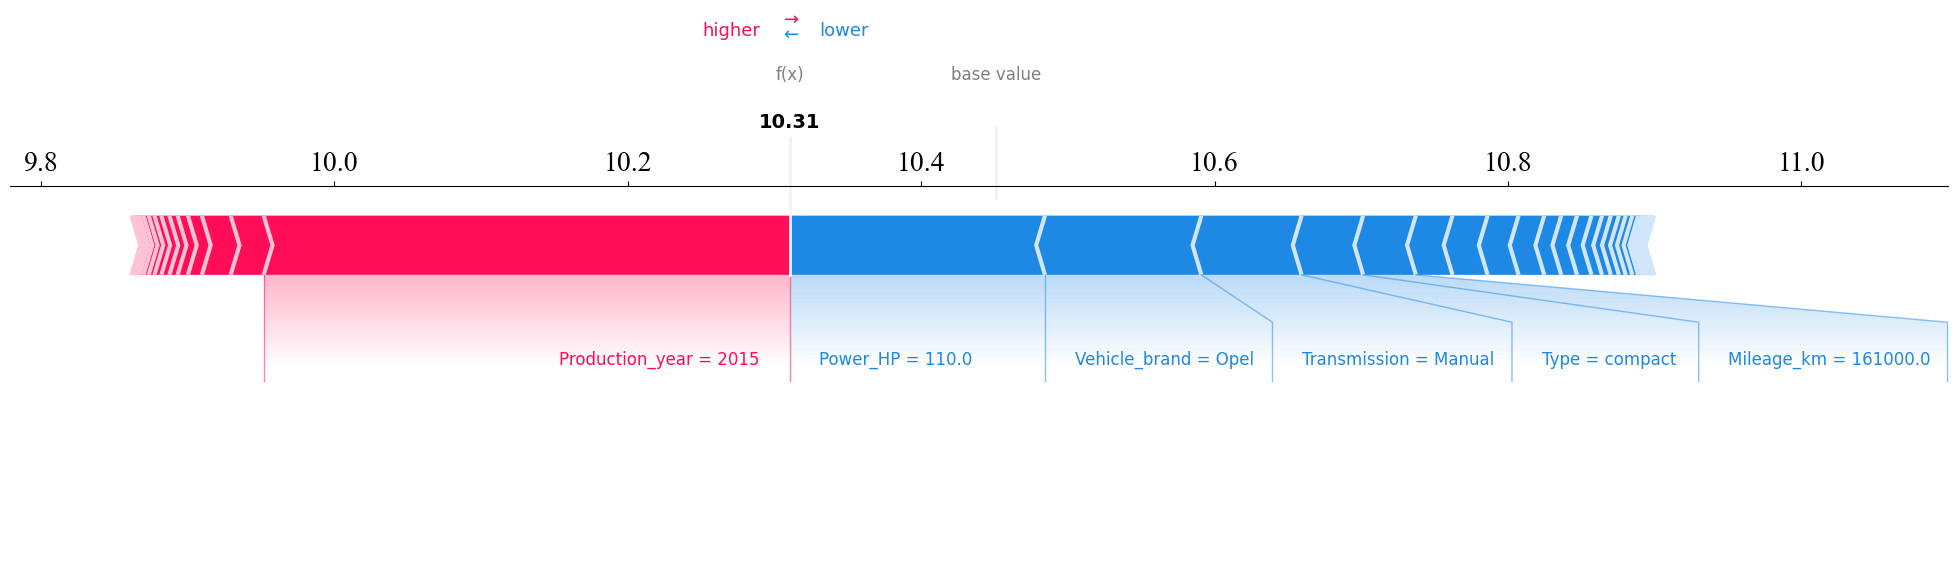

Index: 26638, True value: 9.5397, Predicted value: 11.8836, Residual: 2.3439


<Figure size 640x480 with 0 Axes>

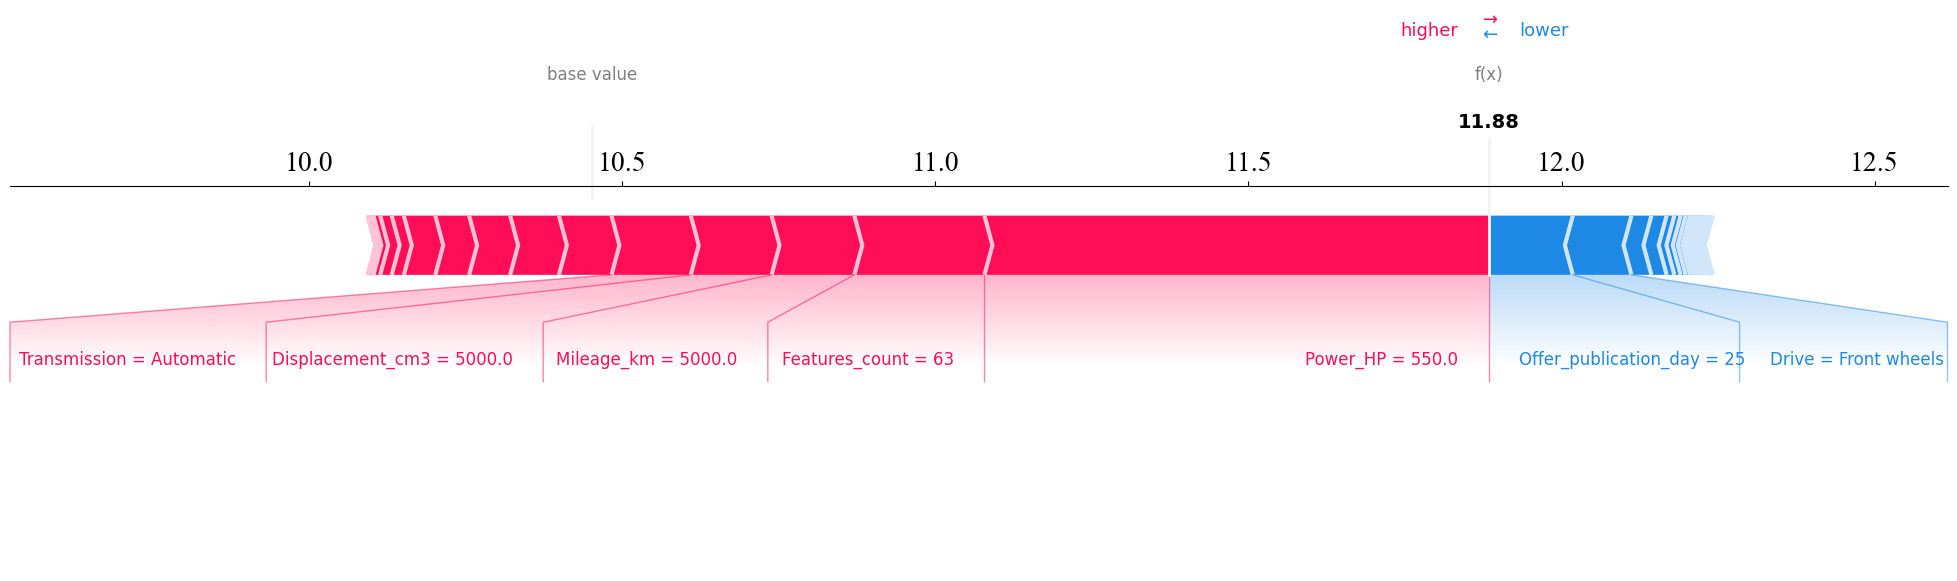

Index: 39403, True value: 7.4390, Predicted value: 9.8379, Residual: 2.3989


<Figure size 640x480 with 0 Axes>

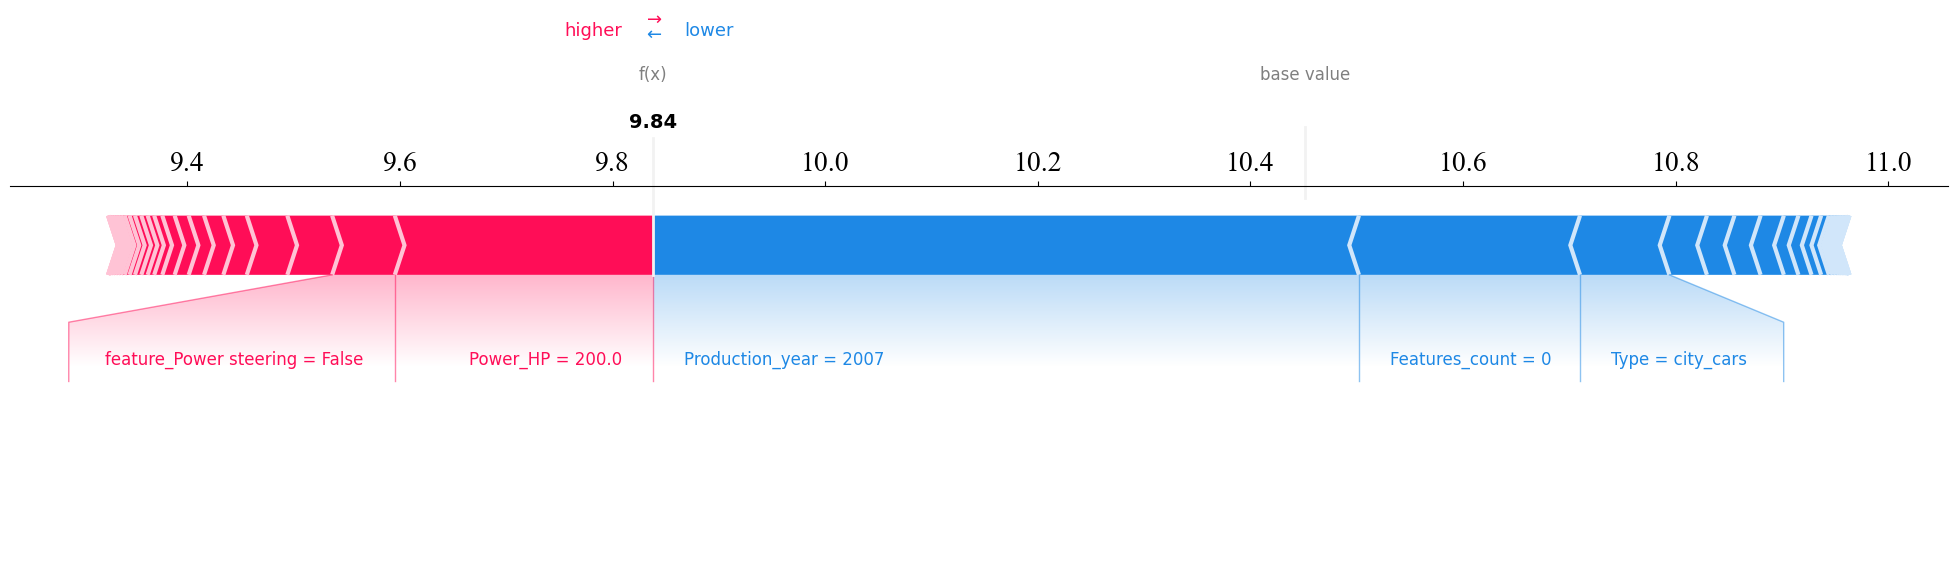

Index: 37907, True value: 8.7797, Predicted value: 11.4083, Residual: 2.6286


<Figure size 640x480 with 0 Axes>

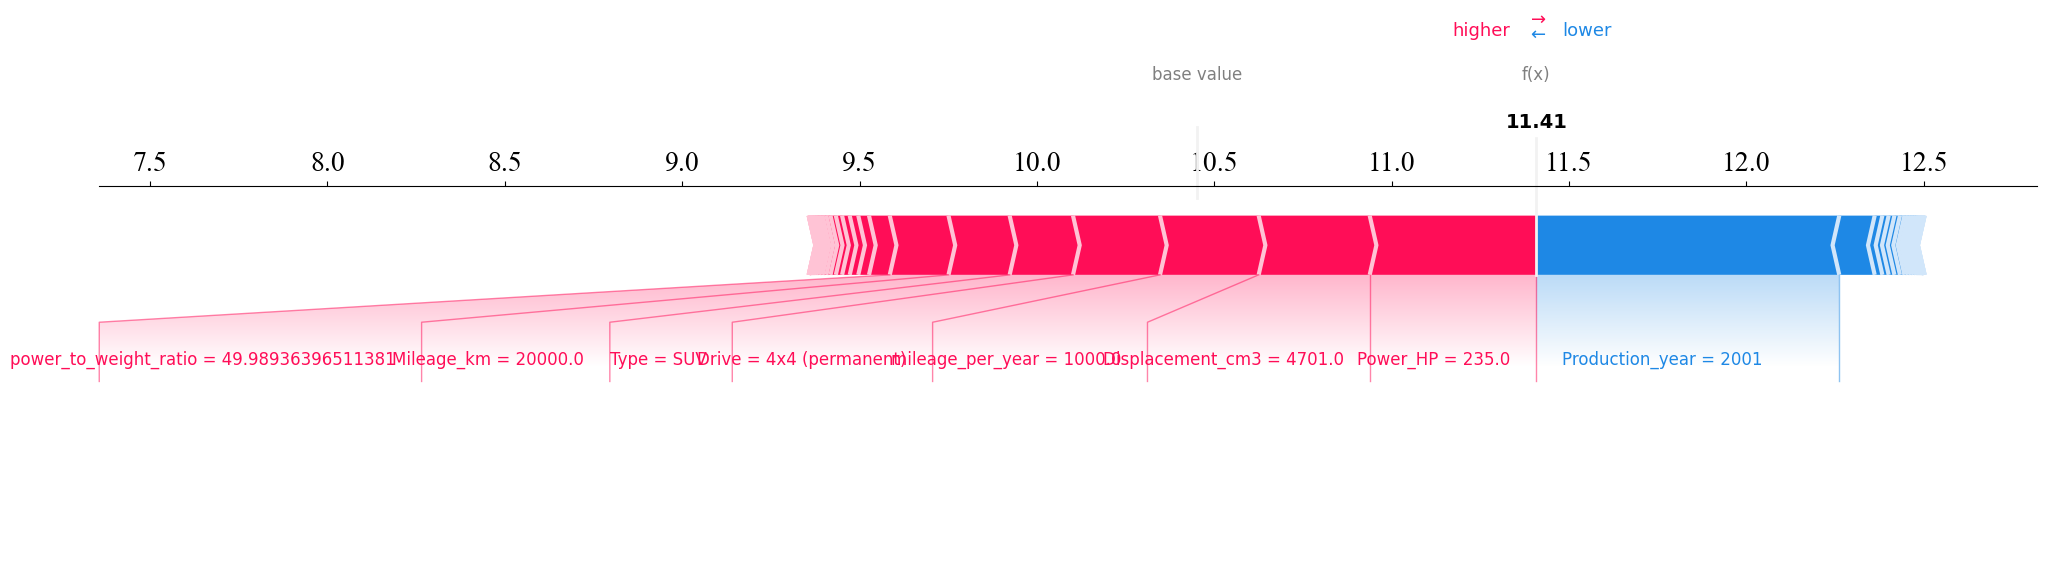

Index: 25632, True value: 8.9491, Predicted value: 11.5888, Residual: 2.6397


<Figure size 640x480 with 0 Axes>

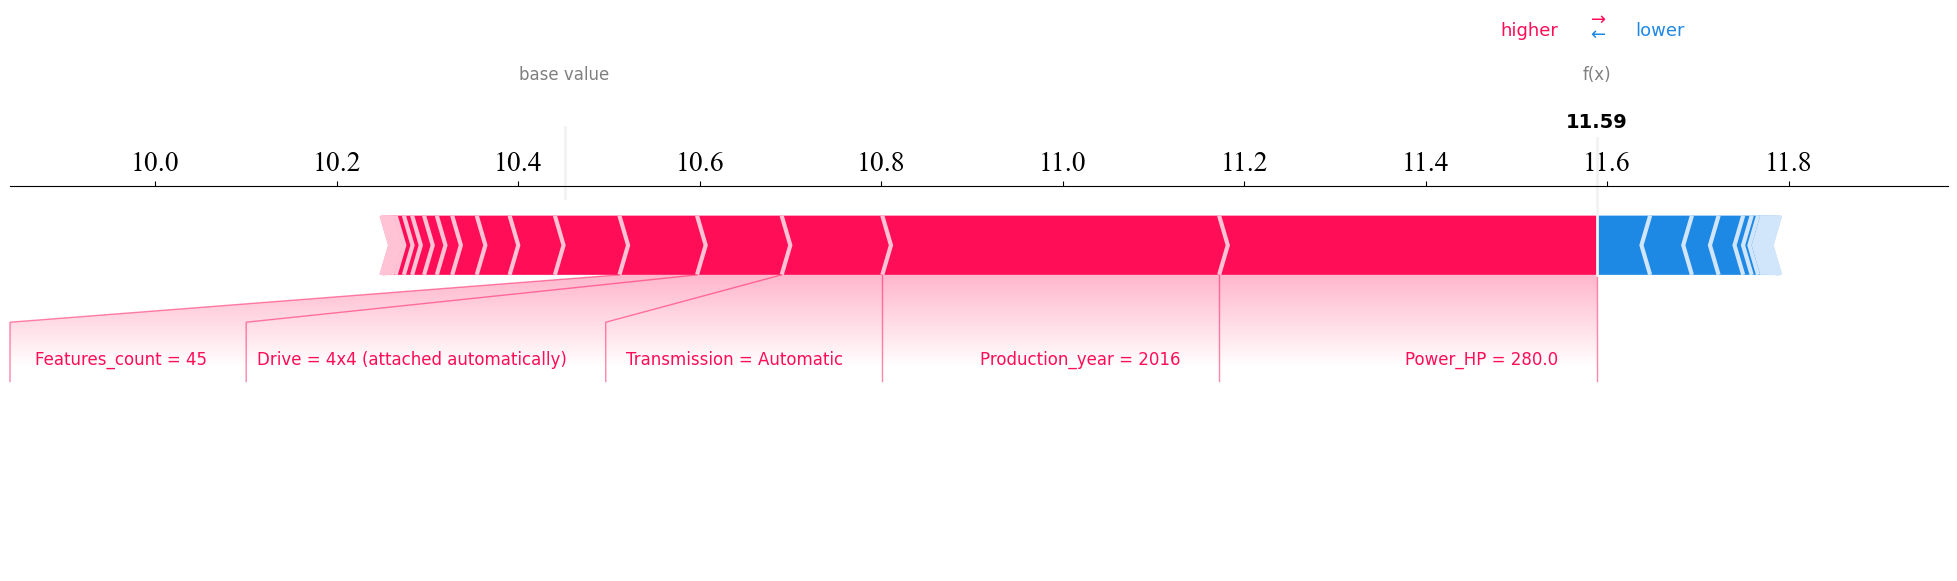

Index: 14846, True value: 7.5181, Predicted value: 10.5429, Residual: 3.0248


<Figure size 640x480 with 0 Axes>

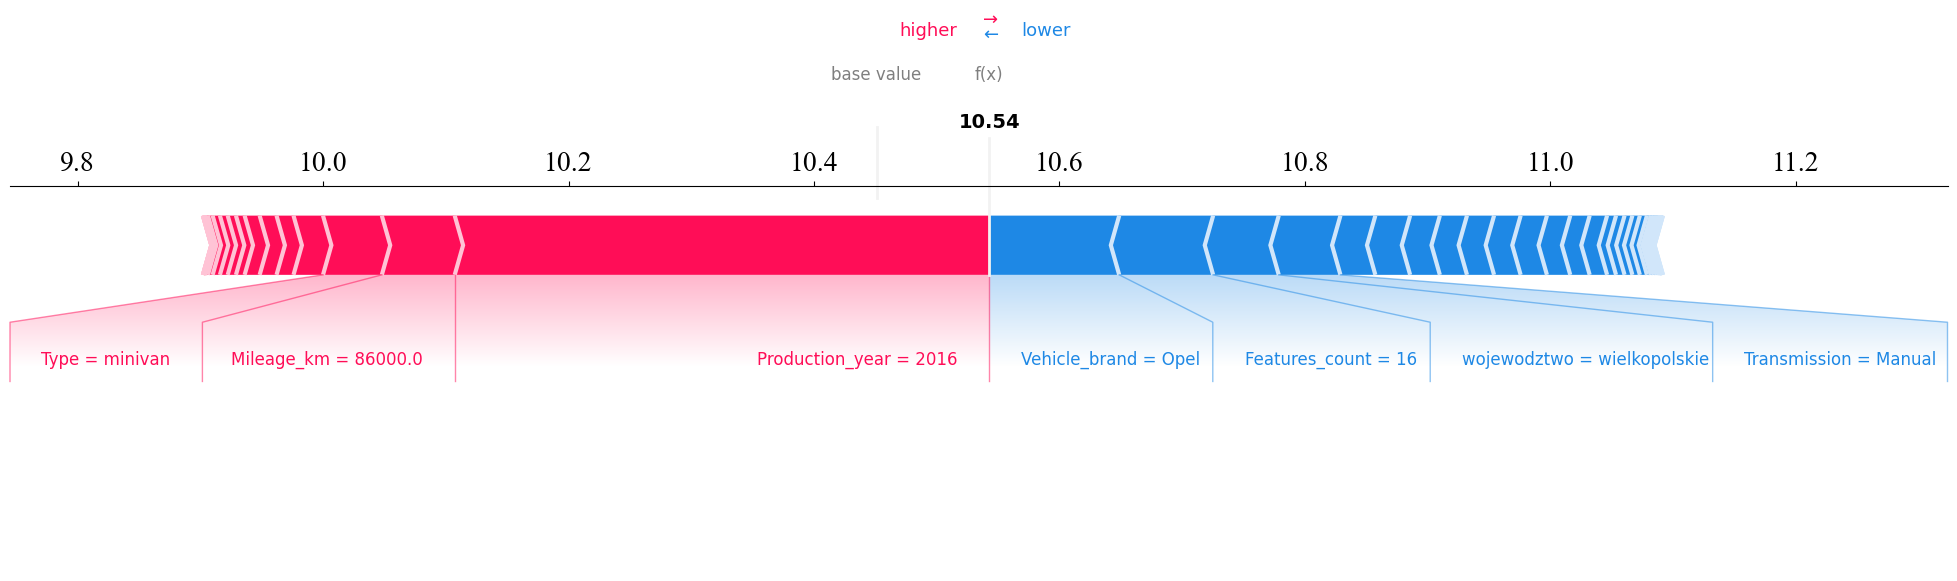

In [18]:
for i in overestimated_indices:
    print(f"Index: {i}, True value: {y_test.loc[i]:.4f}, Predicted value: {y_test_pred[i]:.4f}, Residual: {(y_test_pred[i] - y_test.loc[i]):.4f}")
    shap.plots.force(shap_values[i], matplotlib=True, show=False, contribution_threshold=0.07, figsize=(25, 5))
    plt.yticks(fontsize=20, fontname='Times New Roman', color='Black')
    plt.xticks(fontsize=20, fontname='Times New Roman', color='Black')
    plt.show()
    plt.clf()